In [ ]:
!pip install lime tmu optuna shap catboost hmmlearn -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 22.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 557.1/557.1 kB 49.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 42.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 25.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 29.6 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import importlib, tmu.clause_bank.clause_bank as _cb
import inspect, types

src = inspect.getsource(_cb)
src = src.replace("np.uint32(~0)", "np.iinfo(np.uint32).max")
exec(compile(src, _cb.__file__, 'exec'), _cb.__dict__)

In [ ]:
import math, warnings, optuna, shap, lime, lime.lime_tabular
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX
from hmmlearn.hmm import GaussianHMM
import time

from sklearn import linear_model
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler, PolynomialFeatures, KBinsDiscretizer
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error, mean_absolute_error
from sklearn.inspection import permutation_importance
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, BayesianRidge
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

from tmu.models.regression.vanilla_regressor import TMRegressor
from optuna.samplers import TPESampler
from optuna.pruners import HyperbandPruner
from sklearn.base import clone

optuna.logging.set_verbosity(optuna.logging.WARNING)

ERROR:tmu.clause_bank.clause_bank_cuda:No module named 'pycuda'
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/tmu/clause_bank/clause_bank_cuda.py", line 41, in <module>
    from pycuda._driver import Device, Context
ModuleNotFoundError: No module named 'pycuda'


### pipeline

In [ ]:
PARAM_GRIDS = {
    'RF': {
        'model__n_estimators':      [300, 500, 800],
        'model__max_depth':         [3, 5, 7, None],
        'model__min_samples_leaf':  [2, 3, 5],
        'model__min_samples_split': [2, 5, 10],
        'model__max_features':      ['sqrt', 0.5, 0.7],
    },
    'GB': {
        'model__n_estimators':   [200, 300, 500],
        'model__learning_rate':  [0.01, 0.03, 0.05, 0.1],
        'model__max_depth':      [2, 3, 4],
        'model__subsample':      [0.6, 0.7, 0.8],
        'model__min_samples_leaf': [2, 3, 5],
    },
    'XGB': {
        'model__n_estimators':     [300, 500, 800],
        'model__learning_rate':    [0.01, 0.03, 0.05],
        'model__max_depth':        [2, 3, 4],
        'model__subsample':        [0.6, 0.7, 0.8],
        'model__colsample_bytree': [0.6, 0.7, 0.8],
        'model__reg_alpha':        [0.0, 0.1, 0.5, 1.0],
        'model__reg_lambda':       [0.5, 1.0, 2.0],
        'model__min_child_weight': [1, 3, 5],
    },
    'KNN': {
        'model__n_neighbors': [3, 5, 7, 10, 15],
        'model__weights':     ['uniform', 'distance'],
        'model__metric':      ['euclidean', 'manhattan', 'minkowski'],
        'model__leaf_size':   [20, 30, 40],
    },
    'SVR': {
        'model__C':       [0.1, 1.0, 10.0, 50.0, 100.0],
        'model__epsilon': [0.001, 0.01, 0.05, 0.1],
        'model__gamma':   ['scale', 'auto', 0.01, 0.1],
        'model__kernel':  ['rbf', 'linear'],
    },
    'bayes': {
        'model__alpha_1':  [1e-7, 1e-6, 1e-5],
        'model__alpha_2':  [1e-7, 1e-6, 1e-5],
        'model__lambda_1': [1e-7, 1e-6, 1e-5],
        'model__lambda_2': [1e-7, 1e-6, 1e-5],
        'model__max_iter': [300, 500, 1000],
    },
    'catboost': {
        'model__iterations':    [300, 500, 800],
        'model__learning_rate': [0.01, 0.03, 0.05],
        'model__depth':         [3, 4, 5, 6],
        'model__l2_leaf_reg':   [1.0, 3.0, 5.0, 10.0],
        'model__subsample':     [0.6, 0.7, 0.8],
    },
}

BASE_MODELS = {
    'RF':       RandomForestRegressor(random_state=42, n_jobs=-1),
    'GB':       GradientBoostingRegressor(random_state=42),
    'XGB': XGBRegressor(n_estimators=500, learning_rate=0.03, max_depth=3,
                            subsample=0.7, colsample_bytree=0.7, reg_alpha=0.1,
                            reg_lambda=1.0, random_state=42, objective='reg:squarederror',
                            verbosity=0),
    # XGBRegressor(random_state=42, objective="reg:squarederror",
                            #  tree_method="hist", verbosity=0),
    'KNN':      KNeighborsRegressor(),
    'SVR':      SVR(),
    'bayes':    BayesianRidge(),
    'catboost': CatBoostRegressor(random_state=42, verbose=0),
}

def tune_model(model_name, pipeline_steps_before_model,
               X_train, y_train, n_iter=30, cv_splits=5):
    steps = pipeline_steps_before_model + [('model', BASE_MODELS[model_name])]
    pipe  = Pipeline(steps)
    tscv = TimeSeriesSplit(n_splits=cv_splits)

    search = RandomizedSearchCV(
        estimator          = pipe,
        param_distributions= PARAM_GRIDS[model_name],
        n_iter             = n_iter,
        cv                 = tscv,
        scoring            = 'r2',
        random_state       = 42,
        n_jobs             = -1,
        refit              = True
    )
    search.fit(X_train, y_train)
    print(f"  Best CV R²: {search.best_score_:.4f}")
    print(f"  Best params: {search.best_params_}")
    return search.best_estimator_

In [ ]:
def tune_model_optuna(model_name, pipeline_steps_before_model, X_train, y_train, n_iter=200, cv_splits=5):
    tscv = TimeSeriesSplit(n_splits=cv_splits)

    def objective(trial):
        model = clone(BASE_MODELS[model_name])

        if model_name == "RF":
            params = {
                "n_estimators": trial.suggest_int("n_estimators", 200, 1500),
                "max_depth": trial.suggest_int("max_depth", 2, 20),
                "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 20),
                "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
                "max_features": trial.suggest_float("max_features", 0.3, 1.0),
            }

        elif model_name == "GB":
            params = {
                "n_estimators": trial.suggest_int("n_estimators", 100, 1500),
                "learning_rate": trial.suggest_float("learning_rate", 1e-4, 0.3, log=True),
                "max_depth": trial.suggest_int("max_depth", 2, 10),
                "subsample": trial.suggest_float("subsample", 0.5, 1.0),
                "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 20),
            }

        elif model_name == "XGB":
            params = {
                "n_estimators": trial.suggest_int("n_estimators", 200, 3000),
                "learning_rate": trial.suggest_float("learning_rate", 1e-4, 0.3, log=True),
                "max_depth": trial.suggest_int("max_depth", 2, 12),
                "subsample": trial.suggest_float("subsample", 0.5, 1.0),
                "colsample_bytree": trial.suggest_float("colsample_bytree", 0.4, 1.0),
                "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 100.0, log=True),
                "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 100.0, log=True),
                "min_child_weight": trial.suggest_float("min_child_weight", 0.1, 20.0, log=True),
            }

        elif model_name == "KNN":
            params = {
                "n_neighbors": trial.suggest_int("n_neighbors", 2, 50),
                "weights": trial.suggest_categorical("weights", ["uniform", "distance"]),
                "metric": trial.suggest_categorical("metric", ["euclidean", "manhattan", "minkowski"]),
                "leaf_size": trial.suggest_int("leaf_size", 10, 100),
            }

        elif model_name == "SVR":
            params = {
                "C": trial.suggest_float("C", 1e-3, 1e3, log=True),
                "epsilon": trial.suggest_float("epsilon", 1e-4, 1.0, log=True),
                "gamma": trial.suggest_categorical("gamma", ["scale", "auto"]),
                "kernel": trial.suggest_categorical("kernel", ["rbf", "linear", "poly"]),
            }

        elif model_name == "bayes":
            params = {
                "alpha_1": trial.suggest_float("alpha_1", 1e-8, 1e-3, log=True),
                "alpha_2": trial.suggest_float("alpha_2", 1e-8, 1e-3, log=True),
                "lambda_1": trial.suggest_float("lambda_1", 1e-8, 1e-3, log=True),
                "lambda_2": trial.suggest_float("lambda_2", 1e-8, 1e-3, log=True),
                "max_iter": trial.suggest_int("max_iter", 200, 2000),
            }

        elif model_name == "catboost":
            params = {
                "iterations": trial.suggest_int("iterations", 200, 3000),
                "learning_rate": trial.suggest_float("learning_rate", 1e-4, 0.3, log=True),
                "depth": trial.suggest_int("depth", 2, 12),
                "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1e-3, 100.0, log=True),
                "subsample": trial.suggest_float("subsample", 0.5, 1.0),
            }

        model.set_params(**params)

        pipe = Pipeline(pipeline_steps_before_model + [("model", model)])

        return cross_val_score(pipe, X_train, y_train, cv=tscv, scoring="r2", n_jobs=-1).mean()

    study = optuna.create_study(direction="maximize", sampler=TPESampler(seed=42, multivariate=True), pruner=HyperbandPruner())
    study.optimize(objective, n_trials=n_iter, show_progress_bar=True)

    best_model = clone(BASE_MODELS[model_name])
    best_model.set_params(**study.best_params)

    best_pipe = Pipeline(pipeline_steps_before_model + [("model", best_model)])
    best_pipe.fit(X_train, y_train)

    print(f"Best CV R²: {study.best_value:.6f}")
    print(f"Best params: {study.best_params}")

    return best_pipe

### Visualization  and feature importance ranking

In [ ]:
def standard_importance(fitted_model, pipeline, X_train, y_train, feature_names):
    if hasattr(fitted_model, 'feature_importances_'):
        importances = fitted_model.feature_importances_
    elif hasattr(fitted_model, 'coef_'):
        importances = np.abs(fitted_model.coef_)
    else:
        perm        = permutation_importance(pipeline, X_train, y_train, n_repeats=10, random_state=42)
        importances = perm.importances_mean
    return pd.DataFrame({
        'feature':    feature_names,
        'importance': importances
    }).sort_values('importance', ascending=False).reset_index(drop=True)

def shap_importance(fitted_model, X_train, feature_names):
    X_train_df  = pd.DataFrame(X_train, columns=feature_names)
    tree_models = (RandomForestRegressor, GradientBoostingRegressor,
                   XGBRegressor, CatBoostRegressor)
    if isinstance(fitted_model, tree_models):
        explainer   = shap.TreeExplainer(fitted_model, feature_perturbation="tree_path_dependent")
        shap_values = explainer.shap_values(X_train_df)
    else:
        explainer   = shap.KernelExplainer(
            fitted_model.predict, shap.sample(X_train_df, 50))
        shap_values = explainer.shap_values(X_train_df)
    importances = np.abs(shap_values).mean(axis=0)
    return pd.DataFrame({
        'feature':    feature_names,
        'importance': importances
    }).sort_values('importance', ascending=False).reset_index(drop=True), shap_values, X_train_df

def permutation_importance_ranked(pipeline, X_train, y_train, feature_names):
    perm = permutation_importance(pipeline, X_train, y_train,
                                  n_repeats=20, random_state=42)
    return pd.DataFrame({
        'feature':    feature_names,
        'importance': perm.importances_mean,
        'std':        perm.importances_std
    }).sort_values('importance', ascending=False).reset_index(drop=True)



def lime_importance(fitted_model, X_train, X_test, feature_names, model_name):
    explainer = lime.lime_tabular.LimeTabularExplainer(
        training_data   = X_train,
        feature_names   = feature_names,
        mode            = 'regression',
        discretize_continuous = True,
        random_state    = 42
    )

    all_weights = []
    for i in range(len(X_test)):
        exp         = explainer.explain_instance(
            X_test[i],
            fitted_model.predict,
            num_features = len(feature_names),
            num_samples  = 500
        )
        weights_dict = dict(exp.as_list())
        row          = {f: 0.0 for f in feature_names}
        for key, val in weights_dict.items():
            for fname in feature_names:
                if fname in key:
                    row[fname] = val
                    break
        all_weights.append(row)

    lime_df   = pd.DataFrame(all_weights)

    fi_lime = pd.DataFrame({
        'feature':        feature_names,
        'importance':     lime_df.abs().mean(),
        'mean_effect':    lime_df.mean(),
    }).sort_values('importance', ascending=False).reset_index(drop=True)

    fig, axes = plt.subplots(1, 2, figsize=(14, max(4, len(fi_lime.head(20)) * 0.35)))

    top = fi_lime.head(20)
    axes[0].barh(top['feature'][::-1], top['importance'][::-1], color='mediumpurple')
    axes[0].set_title(f"LIME — Mean |Weight| ({model_name})")
    axes[0].set_xlabel("Mean Absolute LIME Weight")
    axes[0].grid(True, alpha=0.3)

    colors = ['tomato' if v < 0 else 'steelblue' for v in top['mean_effect'][::-1]]
    axes[1].barh(top['feature'][::-1], top['mean_effect'][::-1], color=colors)
    axes[1].axvline(0, color='black', linewidth=0.8, linestyle='--')
    axes[1].set_title(f"LIME — Direction of Effect ({model_name}) Blue=increases CPI, Red=decreases CPI")
    axes[1].set_xlabel("Mean Signed LIME Weight")
    axes[1].grid(True, alpha=0.3)

    plt.suptitle(f"LIME Feature Importance — {model_name}", fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

    return fi_lime

In [ ]:
def plot_macro_bar(fi_df, title):
    fig, ax = plt.subplots(figsize=(7, max(4, len(fi_df) * 0.35)))
    ax.barh(fi_df['feature'][::-1], fi_df['importance'][::-1], color='steelblue')
    ax.set_title(title)
    ax.set_xlabel("Importance")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_permutation(fi_df, model_name):
    fig, ax = plt.subplots(figsize=(7, max(4, len(fi_df) * 0.35)))
    top = fi_df.head(20)
    ax.barh(top['feature'][::-1], top['importance'][::-1],
            xerr=top['std'][::-1] if 'std' in top.columns else None,
            color='mediumseagreen', capsize=3)
    ax.set_title(f"Permutation Importance — Top 20\n({model_name})")
    ax.set_xlabel("Mean accuracy decrease (±std)")
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_shap(shap_values, X_train_df, model_name):
    plt.figure()
    shap.summary_plot(shap_values, X_train_df, plot_type="bar", show=False)
    plt.title(f"SHAP — Mean |SHAP| ({model_name})")
    plt.tight_layout()
    plt.show()

    plt.figure()
    shap.summary_plot(shap_values, X_train_df, show=False)
    plt.title(f"SHAP — Direction & Magnitude ({model_name})")
    plt.tight_layout()
    plt.show()


In [ ]:
def compute_and_plot_importance(strategy, fitted_model, pipeline,
                                X_train, y_train, feature_names,
                                macro_vars, model_name, use_macro,
                                X_test=None):
    run_standard    = strategy in ('standard',    'all')
    run_shap        = strategy in ('shap',        'all')
    run_permutation = strategy in ('permutation', 'all')
    run_lime        = strategy in ('lime',        'all')

    fi_standard = fi_shap = fi_perm = fi_lime = None

    if run_standard:
        fi_standard = standard_importance(fitted_model, pipeline,
                                          X_train, y_train, feature_names)
        macro_fi    = fi_standard[fi_standard['feature'].apply(
                          lambda f: any(f == m or f.startswith(m + "_")
                                        for m in macro_vars))].reset_index(drop=True)
        other_fi    = fi_standard[~fi_standard.index.isin(macro_fi.index)].reset_index(drop=True)
        if use_macro and not macro_fi.empty:
            plot_macro_bar(macro_fi, f"Standard Importance — Macro\n({model_name})")
        if not other_fi.empty:
            plot_macro_bar(other_fi, f"Standard Importance — Other\n({model_name})")

    if run_shap:
        fi_shap, shap_values, X_train_df = shap_importance(fitted_model, X_train, feature_names)
        plot_shap(shap_values, X_train_df, model_name)

    if run_permutation:
        fi_perm = permutation_importance_ranked(pipeline, X_train, y_train, feature_names)
        plot_permutation(fi_perm, model_name)

    if run_lime:
        if X_test is not None:
            fi_lime = lime_importance(fitted_model, X_train, X_test,
                                      feature_names, model_name)
        else:
            print("LIME skipped — X_test not passed to compute_and_plot_importance")

    return fi_standard, fi_shap, fi_perm, fi_lime


### Load dataset

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Forecasting-Agent-for-Fintech/data/macro/combined_macro_data.csv", parse_dates=["date"])

macro_vars = [
        "wti_price","fedfunds","nfci","anfci","nfci_risk","nfci_credit",
        "nfci_leverage","nfci_nonfinancial_leverage","gdp","gdp_growth","ppi",
        "trade_balance","unrate","usd_index"
    ]

## Single Prediction

In [ ]:
def run_arima(y_train, y_test, test_dates, X_train=None, X_test=None, use_macro=False):
    if X_train is not None:
          lag_cols = [c for c in X_train.columns if c.endswith('_lag1')]
          X_train  = X_train[lag_cols] if len(lag_cols) else None
          X_test   = X_test[lag_cols]  if len(lag_cols) else None

    exog_train = X_train if use_macro and X_train is not None else None
    exog_test  = X_test  if use_macro and X_test  is not None else None

    best_result = None
    best_aic    = np.inf

    for p in [1, 2, 4]:
        for d in [0, 1]:
            for q in [0, 1]:
                try:
                    m = SARIMAX(y_train, exog=exog_train,
                                order=(p, d, q),
                                seasonal_order=(1, 0, 0, 4),
                                enforce_stationarity=False,
                                enforce_invertibility=False).fit(disp=False)
                    if m.aic < best_aic:
                        best_aic    = m.aic
                        best_result = m
                except Exception:
                    continue
    start = time.time()
    predictions = np.array(best_result.forecast(steps=len(y_test), exog=exog_test))
    end = time.time()

    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2   = r2_score(y_test, predictions)
    mape = mean_absolute_percentage_error(y_test, predictions) * 100
    mae  = mean_absolute_error(y_test, predictions)

    results = pd.DataFrame({
        "date":             test_dates.values,
        "actual_cpiret":    y_test.values,
        "predicted_cpiret": predictions
    })

    print(f"\n{'='*65}")
    print(f"ARIMA — Best AIC: {best_aic:.2f}")
    print(f"{'Date':<15} {'Actual':>12} {'Predicted':>12} {'Error':>12}")
    print(f"{'-'*65}")
    for _, row in results.iterrows():
        error = abs(row['actual_cpiret'] - row['predicted_cpiret'])
        print(f"{str(row['date'])[:10]:<15} {row['actual_cpiret']:>12.6f} {row['predicted_cpiret']:>12.6f} {error:>12.6f}")
    print(f"{'-'*65}")
    print(f"{'RMSE:':>45} {rmse:>12.6f}")
    print(f"{'MAE:':>45}  {mae:>12.4f}")
    print(f"Inference time: {(end - start) * 1000:.3f} ms")
    print(f"{'='*65}")
    print("\nNote: ARIMA coefficients:")
    print(best_result.params)

    fig, ax = plt.subplots(figsize=(10, 4))
    x = range(len(results))
    ax.plot(x, results["actual_cpiret"],    marker="o", label="Actual",    linewidth=2)
    ax.plot(x, results["predicted_cpiret"], marker="o", label="Predicted", linewidth=2)
    ax.set_xticks(x)
    ax.set_xticklabels([str(d)[:10] for d in results["date"]], rotation=45)
    ax.set_xlabel("Quarter")
    ax.set_ylabel("cpiret")
    ax.set_title(f"CPI Prediction — ARIMA\n(RMSE={rmse:.6f}  MAE={mae:.4f})")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return results, rmse, mae, mape, r2


In [ ]:
def _shap_guided_binarise(X_train, X_test, model, min_bins=5, max_bins=20):
    """
    Binarise each feature with n_bins proportional to its SHAP importance.
    High-importance features → max_bins (20), low-importance → min_bins (5).
    """
    # explainer   = shap.Explainer(model, X_train) #,silent=True
    explainer = shap.TreeExplainer(model, feature_perturbation="tree_path_dependent")
    # shap_values = explainer(X_train).values
    shap_values = explainer.shap_values(X_train)
    mean_abs    = np.abs(shap_values).mean(axis=0)

    imp_min, imp_max = mean_abs.min(), mean_abs.max()
    if imp_max - imp_min < 1e-9:
        norm = np.ones_like(mean_abs)
    else:
        norm = (mean_abs - imp_min) / (imp_max - imp_min)

    n_bins_per_feat = np.round(
        min_bins + norm * (max_bins - min_bins)
    ).astype(int)

    print(f"\n  SHAP-guided bins — min:{n_bins_per_feat.min()} "
          f"max:{n_bins_per_feat.max()} "
          f"mean:{n_bins_per_feat.mean():.1f}")

    # Binarise each feature independently
    tr_cols, te_cols = [], []
    for j, nb in enumerate(n_bins_per_feat):
        binner = KBinsDiscretizer(n_bins=nb, encode='ordinal', strategy='quantile')
        tr_cols.append(binner.fit_transform(X_train[:, [j]]))
        te_cols.append(binner.transform(X_test[:, [j]]))

    X_tr_bits = np.hstack(tr_cols).astype(np.uint32)
    X_te_bits = np.hstack(te_cols).astype(np.uint32)
    return X_tr_bits, X_te_bits, n_bins_per_feat

In [ ]:

def fit_regime_hmm(df, n_regimes=2, regime_features=None):
    if regime_features is None:
        regime_features = [c for c in ["nfci", "fedfunds", "unrate", "cpiret_lag1"]
                           if c in df.columns]

    if len(regime_features) == 0:
        raise ValueError("No regime features found in DataFrame.")

    X_reg = df[regime_features].ffill().bfill().values
    regime_scaler = StandardScaler()
    X_reg_sc      = regime_scaler.fit_transform(X_reg)

    hmm = GaussianHMM(
        n_components  = n_regimes,
        covariance_type = "full",
        n_iter        = 200,
        random_state  = 42
    )
    hmm.fit(X_reg_sc)
    regimes = hmm.predict(X_reg_sc)

    # Identify which label = recession: higher mean unrate / nfci = stress
    if "unrate" in regime_features:
        stress_idx = np.argmax([
            X_reg_sc[regimes == r, regime_features.index("unrate")].mean()
            for r in range(n_regimes)
        ])
    else:
        stress_idx = np.argmax([
            X_reg_sc[regimes == r].mean()
            for r in range(n_regimes)
        ])

    # Remap so regime 1 = stress/recession, 0 = expansion
    if stress_idx == 0:
        regimes = 1 - regimes

    counts = {0: (regimes == 0).sum(), 1: (regimes == 1).sum()}
    print(f"  HMM regimes — Expansion: {counts[0]}q | Stress/Recession: {counts[1]}q")
    print(f"  Features used: {regime_features}")

    return hmm, regimes, regime_scaler, regime_features

def detect_regime(hmm, regime_scaler, regime_features, X_row_df, stress_idx_is_1=True):
    """
    Predict regime for a single row (as DataFrame).
    Returns 0 (expansion) or 1 (recession/stress).
    """
    avail = [c for c in regime_features if c in X_row_df.columns]
    X_reg = X_row_df[avail].values.reshape(1, -1)
    X_sc  = regime_scaler.transform(X_reg)
    label = hmm.predict(X_sc)[0]
    return int(label)


### TM

In [ ]:
def run_tsetlin(X_train, X_test, y_train, y_test, test_dates,
                feature_names, importance_strategy, feature_selection,
                n_bins=10, epochs=30, tune=True, n_trials=50,
                use_macro=True, shap_binarise=False,
                min_bins=5, max_bins=30,
                use_regime=False, n_regimes=2, regime_features=["nfci", "fedfunds", "unrate", "cpiret_lag1"]):
    # Drop contemporaneous macro cols
    if not use_macro:
        drop_cols = [c for c in X_train.columns
                     if any(c == m or c.startswith(f"{m}_") for m in macro_vars)]
        X_train = X_train.drop(columns=drop_cols, errors='ignore')
        X_test  = X_test.drop(columns=drop_cols, errors='ignore')

    raw_macro_in_X = [c for c in X_train.columns if c in macro_vars]
    X_train = X_train.drop(columns=raw_macro_in_X, errors='ignore')
    X_test  = X_test.drop(columns=raw_macro_in_X, errors='ignore')
    feature_names = X_train.columns.tolist()

    X_train_df = X_train.copy()
    X_test_df  = X_test.copy()

    # Regime detection (only if requested)
    train_regimes = None
    if use_regime:
        print("\n[Regime Detection]")
        hmm, train_regimes, regime_scaler, reg_feats = fit_regime_hmm(
            X_train_df, n_regimes=n_regimes, regime_features=regime_features
        )

    # Scale + select
    scaler   = RobustScaler()
    X_tr_sc  = scaler.fit_transform(X_train_df.values)
    X_te_sc  = scaler.transform(X_test_df.values)
    centers, scales = scaler.center_, scaler.scale_

    if (use_macro == True and feature_selection == True) or use_macro == False:
      TOP_K_SEL = min(10, X_tr_sc.shape[1])
    else:
      TOP_K_SEL = X_tr_sc.shape[1]
    selector  = SelectKBest(score_func=f_regression, k=TOP_K_SEL)
    X_tr_sel  = selector.fit_transform(X_tr_sc, y_train)
    selected_features = np.array(feature_names)[selector.get_support()].tolist()

    # Lag/roll indices for recursive propagation in scaled space
    all_feat = list(X_test_df.columns)
    lag_idx  = {lag: all_feat.index(f"cpiret_lag{lag}")
                for lag in [1, 2, 4] if f"cpiret_lag{lag}" in all_feat}
    roll_idx = {w:   all_feat.index(f"cpiret_roll{w}")
                for w   in [4, 8]   if f"cpiret_roll{w}"  in all_feat}

    # Base model
    base_model = XGBRegressor(n_estimators=500, learning_rate=0.03, max_depth=3,
                            subsample=0.7, colsample_bytree=0.7, reg_alpha=0.1,
                            reg_lambda=1.0, random_state=42, objective='reg:squarederror',
                            verbosity=0)

    base_model.fit(X_tr_sel, y_train)
    train_pred = base_model.predict(X_tr_sel)

    #  Recursive test prediction
    start       = time.time()
    X_te_sc_rec = X_te_sc.copy()
    test_pred   = []

    for i in range(len(X_te_sc_rec)):
        pred_i = float(base_model.predict(selector.transform(X_te_sc_rec[[i]]))[0])
        test_pred.append(pred_i)
        for lag, col_i in lag_idx.items():
            future = i + lag
            if future < len(X_te_sc_rec):
                X_te_sc_rec[future, col_i] = (pred_i - centers[col_i]) / scales[col_i]
        for w, col_i in roll_idx.items():
            future = i + 1
            if future < len(X_te_sc_rec):
                wnd = test_pred[-w:] if len(test_pred) >= w else test_pred
                X_te_sc_rec[future, col_i] = (np.mean(wnd) - centers[col_i]) / scales[col_i]

    test_pred    = np.array(test_pred, dtype=np.float32)
    X_te_sel_rec = selector.transform(X_te_sc_rec)
    base_rmse    = math.sqrt(mean_squared_error(y_test, test_pred))

    # Residuals
    y_train_arr = np.asarray(y_train, dtype=np.float32)
    y_test_arr  = np.asarray(y_test,  dtype=np.float32)
    residuals   = y_train_arr - train_pred.astype(np.float32)
    resid_mean  = float(np.mean(residuals))
    resid_std   = float(np.std(residuals)) if np.std(residuals) > 1e-6 else 1.0
    resid_sc    = ((residuals - resid_mean) / resid_std).astype(np.float32)
    clip_val_global = float(np.abs(residuals).max()) * 2.0

    # Binarise helper
    def _binarise(X_tr, X_te, ref_model=None):
        if shap_binarise and ref_model is not None:
            return _shap_guided_binarise(X_tr, X_te, ref_model, min_bins, max_bins)
        b = KBinsDiscretizer(n_bins=n_bins, encode='ordinal', strategy='quantile')
        return b.fit_transform(X_tr).astype(np.uint32), \
               b.transform(X_te).astype(np.uint32), b

    #  Optuna tuning (shared params)
    if tune:
        print("\n[Optuna Tuning]")
        X_all_b, _, _ = _binarise(X_tr_sel, X_tr_sel, base_model)
        resid_sc_all  = ((residuals - residuals.mean()) /
                         (float(np.std(residuals)) or 1.0)).astype(np.float32)
        split      = int(0.8 * len(X_all_b))
        X_opt_tr   = X_all_b[:split];  y_opt_tr   = resid_sc_all[:split]
        X_opt_val  = X_all_b[split:];  y_full_val = y_train_arr[split:]
        base_val   = train_pred[split:].astype(np.float32)

        def objective(trial):
            clauses = trial.suggest_int("number_of_clauses", 50, 2000)
            T       = trial.suggest_int("T", 10, 500)
            s       = trial.suggest_float("s", 1.0, 10.0)
            tm = TMRegressor(number_of_clauses=clauses, T=T, s=s,
                             seed=42, weighted_clauses=True)
            for _ in range(30):
                tm.fit(X=X_opt_tr, Y=y_opt_tr)
            rp = tm.predict(X_opt_val).astype(np.float32)
            return math.sqrt(mean_squared_error(
                y_full_val, base_val + rp * resid_std + resid_mean))

        study = optuna.create_study(direction="minimize",
                                    sampler=optuna.samplers.TPESampler(seed=42))
        study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
        best_params = study.best_params
        print(f"Best: {best_params}  RMSE: {study.best_value:.4f}")
    else:
        best_params = {'number_of_clauses': 350, 'T': 50, 's': 3.5}

    def _make_tm():
        return TMRegressor(**best_params, seed=42, weighted_clauses=True)

    def _fit_tm(X_bits, y_sc):
        tm = _make_tm()
        for _ in range(epochs):
            tm.fit(X=X_bits, Y=y_sc)
        return tm

    # Branch: regime vs non-regime
    if use_regime:
        print("\n[Regime-Conditional TM Training]")
        regime_tms = {}
        for r in range(n_regimes):
            mask = (train_regimes == r)
            label = "Stress" if r == 1 else "Expand"
            print(f"  Regime {r} ({label}): {mask.sum()} quarters")
            if mask.sum() < 10:
                print(f"  → Too few samples, using fallback")
                regime_tms[r] = None
                continue
            X_r, y_r, p_r = X_tr_sel[mask], y_train_arr[mask], train_pred[mask]
            res_r   = y_r - p_r.astype(np.float32)
            rm, rs  = float(np.mean(res_r)), float(np.std(res_r)) or 1.0
            rsc_r   = ((res_r - rm) / rs).astype(np.float32)
            cv_r    = float(np.abs(res_r).max()) * 2.0
            Xtr_b, _, binner = _binarise(X_r, X_r, base_model)
            tm_r = _fit_tm(Xtr_b, rsc_r)
            regime_tms[r] = dict(tm=tm_r, binner=binner, rm=rm, rs=rs,
                                  cv=cv_r, X_r=X_r)

        # Fallback TM (all data)
        Xfb_b, _, fb_binner = _binarise(X_tr_sel, X_tr_sel, base_model)
        tm_fb = _fit_tm(Xfb_b, resid_sc)

        def _regime_correct(X_sel_i, regime_i):
            rtm = regime_tms.get(regime_i)
            if rtm:
                if shap_binarise:
                    _, Xb_i, _ = _binarise(rtm["X_r"], X_sel_i, base_model)
                else:
                    Xb_i = rtm["binner"].transform(X_sel_i).astype(np.uint32)
                c = float(rtm["tm"].predict(Xb_i)[0])
                return np.clip(c * rtm["rs"] + rtm["rm"], -rtm["cv"], rtm["cv"])
            else:
                if shap_binarise:
                    _, Xb_i, _ = _binarise(X_tr_sel, X_sel_i, base_model)
                else:
                    Xb_i = fb_binner.transform(X_sel_i).astype(np.uint32)
                c = float(tm_fb.predict(Xb_i)[0])
                return np.clip(c * resid_std + resid_mean, -clip_val_global, clip_val_global)

        # Test correction with regime
        test_pred_regime = []
        test_regimes     = []
        for i in range(len(X_te_sel_rec)):
            ri = detect_regime(hmm, regime_scaler, reg_feats, X_test_df.iloc[[i]])
            test_regimes.append(ri)
            corr = _regime_correct(X_te_sel_rec[[i]], ri)
            test_pred_regime.append(float(test_pred[i]) + 0.2 * corr)
        final_test_pred = np.array(test_pred_regime, dtype=np.float32)

        # Calibration — regime-conditional training predictions
        y_pred_tr_all = np.zeros_like(train_pred)
        for r in range(n_regimes):
            mask = (train_regimes == r)
            if mask.sum() == 0:
                continue
            rtm = regime_tms.get(r)
            if rtm:
                if shap_binarise:
                    Xr_b, _, _ = _binarise(rtm["X_r"], X_tr_sel[mask], base_model)
                else:
                    Xr_b = rtm["binner"].transform(X_tr_sel[mask]).astype(np.uint32)
                cr = rtm["tm"].predict(Xr_b).astype(np.float32)
                cr = np.clip(cr * rtm["rs"] + rtm["rm"], -rtm["cv"], rtm["cv"])
            else:
                if shap_binarise:
                    Xr_b, _, _ = _binarise(X_tr_sel, X_tr_sel[mask], base_model)
                else:
                    Xr_b = fb_binner.transform(X_tr_sel[mask]).astype(np.uint32)
                cr = tm_fb.predict(Xr_b).astype(np.float32)
                cr = np.clip(cr * resid_std + resid_mean,
                             -clip_val_global, clip_val_global)
            y_pred_tr_all[mask] = train_pred[mask] + 0.2 * cr

    else:
        X_tr_bits, X_te_bits, _ = _binarise(X_tr_sel, X_te_sel_rec, base_model)
        tm = _fit_tm(X_tr_bits, resid_sc)

        resid_pred_te = tm.predict(X_te_bits).astype(np.float32)
        corr_te = np.clip(resid_pred_te * resid_std + resid_mean,
                          -clip_val_global, clip_val_global)
        final_test_pred = test_pred + 0.2 * corr_te

        resid_pred_tr = tm.predict(X_tr_bits).astype(np.float32)
        y_pred_tr_all = (train_pred.astype(np.float32)
                         + np.clip(resid_pred_tr * resid_std + resid_mean,
                                   -clip_val_global, clip_val_global))
        test_regimes = None

    calibrator = LinearRegression()
    calibrator.fit(y_pred_tr_all.reshape(-1, 1), y_train_arr)
    y_pred = final_test_pred
    # calibrator.predict(
        # final_test_pred.reshape(-1, 1)).ravel().astype(np.float32)
    end = time.time()

    rmse = math.sqrt(mean_squared_error(y_test_arr, y_pred))
    mae  = mean_absolute_error(y_test_arr, y_pred)
    mape = mean_absolute_percentage_error(y_test_arr, y_pred) * 100
    r2   = r2_score(y_test_arr, y_pred)

    results = pd.DataFrame({
        "date":            test_dates.values,
        "actual":          y_test_arr,
        "predicted":       y_pred,
        "base_prediction": test_pred,
        **({"regime": test_regimes} if test_regimes is not None else {})
    })

    fi_perm = None
    try:
        perm = permutation_importance(
            base_model, X_te_sel_rec, y_test,
            n_repeats=10, random_state=42,
            scoring='neg_root_mean_squared_error'
        )
        fi_perm = (pd.DataFrame({"feature":    selected_features,
                                  "importance": perm.importances_mean})
                   .sort_values("importance", ascending=False))
    except Exception as e:
        print(f"Permutation importance failed: {e}")

    parts = ["XGB+TM"]
    if shap_binarise: parts.append("SHAP")
    if use_regime:    parts.append("Regime")
    mode_label = " + ".join(parts)

    print(f"\n{'='*65}")
    print(f"{mode_label}")
    print(f"Base RMSE: {base_rmse:.5f}  →  Final RMSE: {rmse:.5f}")
    print(f"{'Date':<15} {'Actual':>12} {'Predicted':>12} {'Error':>10}"
          + (f" {'Regime':>8}" if test_regimes else ""))
    print(f"{'-'*65}")
    for _, row in results.iterrows():
        error = abs(row['actual'] - row['predicted'])
        regime_str = (f" {'Stress' if row['regime'] == 1 else 'Expand':>8}"
                      if test_regimes else "")
        print(f"{str(row['date'])[:10]:<15} {row['actual']:>12.6f} "
              f"{row['predicted']:>12.6f} {error:>10.6f}{regime_str}")
    print(f"{'-'*65}")
    print(f"{'MAE:':>45} {mae:.5f}")
    print(f"{'RMSE:':>45} {rmse:.5f}")
    print(f"{'MAPE (%):':>45} {mape:.2f}")
    print(f"{'R²:':>45} {r2:.4f}")
    print(f"Inference time: {(end - start) * 1000:.3f} ms")
    print(f"{'='*65}")

    fig, ax = plt.subplots(figsize=(10, 4))
    x = range(len(results))
    if use_regime and test_regimes:
        for i, (_, row) in enumerate(results.iterrows()):
            if row['regime'] == 1:
                ax.axvspan(i - 0.5, i + 0.5, alpha=0.12, color='red',
                           label='Stress' if i == results['regime'].eq(1).idxmax() else "")
    ax.plot(x, results["actual"],          marker="o", label="Actual",    linewidth=2)
    ax.plot(x, results["base_prediction"], marker="s", label="Base XGB",  linewidth=1.5,
            linestyle="--", alpha=0.6)
    ax.plot(x, results["predicted"],       marker="o", label="TM Corrected", linewidth=2)
    ax.set_xticks(list(x))
    ax.set_xticklabels([str(d)[:10] for d in results["date"]], rotation=45)
    ax.set_xlabel("Quarter")
    ax.set_ylabel("CPI Return")
    ax.set_title(f"CPI — {mode_label}\n"
                 f"Base RMSE={base_rmse:.5f} → Final RMSE={rmse:.5f} | MAE={mae:.5f}")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return results, rmse, mae, mape, r2, fi_perm

### Forecasting

In [ ]:
def CPI_prediction(data, use_macro, model,
                   use_scaling, feature_selection=True, n_features=10,
                   importance_strategy='standard',
                   tune=False, shap_binarise=False,
                   use_regime=False, n_regimes=2, regime_features=None,
                   n_iter=30, cv_splits=5):

    df = data.sort_values("date").reset_index(drop=True)

    for lag in [1, 2, 3, 4]:
        df[f"cpiret_lag{lag}"] = df["cpiret"].shift(lag)
    for col in macro_vars:
        df[f"{col}_lag1"] = df[col].shift(1)#creating lag1 for all macro vars
    for w in [2, 4]:
      df[f"cpiret_roll{w}"] = df["cpiret"].shift(1).rolling(w).mean()

    df = df.dropna().reset_index(drop=True)
    dates = df["date"]

    X = df.drop(columns=["cpiret", "date"])
    X = X.drop(columns=[c for c in macro_vars if c in X.columns], errors='ignore')#keeping only lag macro vars
    y = df["cpiret"]

    if not use_macro:
        drop_cols = macro_vars + [c for c in X.columns
                                  if any(c.startswith(m) for m in macro_vars)]
        X = X.drop(columns=drop_cols, errors="ignore")
    test_quarters=8
    X_train       = X.iloc[:-test_quarters]
    X_test        = X.iloc[-test_quarters:]
    y_train       = y.iloc[:-test_quarters]
    y_test        = y.iloc[-test_quarters:]
    test_dates    = dates.iloc[-test_quarters:]
    feature_names = X.columns.tolist()

    print(f"Total: {len(X)} | Train: {len(X_train)} | Test: {len(X_test)} | Features: {len(feature_names)}")

    if model == 'arima':
        return run_arima(y_train, y_test, test_dates,
                         X_train if use_macro else None,
                         X_test  if use_macro else None,
                         use_macro)
    if model == 'tsetlin':
        return run_tsetlin(X_train, X_test,
                       y_train, y_test, test_dates,
                       feature_names, importance_strategy, feature_selection=feature_selection, tune=tune,
                       use_macro=use_macro,
                       shap_binarise=shap_binarise,
                       use_regime=use_regime,
                       n_regimes=n_regimes,
                       regime_features=regime_features)

    pre_steps = []
    if use_scaling:
        pre_steps.append(('scaler', RobustScaler()))
    if feature_selection:
        pre_steps.append(('selector', SelectKBest(f_regression,
                                                   k=min(n_features, X.shape[1]))))# Top n features selected according to selectKbest

    if tune and model in PARAM_GRIDS:
        print(f"\nTuning {model} with TimeSeriesSplit (n_iter={n_iter}, cv={cv_splits})...")
        # best_pipeline = tune_model(model, pre_steps, X_train, y_train,
        #                            n_iter=n_iter, cv_splits=cv_splits)
        best_pipeline = tune_model_optuna(model, pre_steps, X_train, y_train,
                              n_iter=n_iter, cv_splits=cv_splits)
    else:
        default_models = {
            'RF':       RandomForestRegressor(n_estimators=500, max_depth=5,
                            min_samples_leaf=3, random_state=42, n_jobs=-1),
            'GB':       GradientBoostingRegressor(n_estimators=300, learning_rate=0.05,
                            max_depth=3, min_samples_leaf=3, subsample=0.8, random_state=42),
            'XGB':      XGBRegressor(n_estimators=500, learning_rate=0.03, max_depth=3,
                            subsample=0.7, colsample_bytree=0.7, reg_alpha=0.1,
                            reg_lambda=1.0, random_state=42, objective='reg:squarederror',
                            verbosity=0),
            'KNN':      KNeighborsRegressor(n_neighbors=7, weights='distance'),
            'SVR':      SVR(kernel='rbf', C=10.0, epsilon=0.01, gamma='scale'),
            'bayes':    BayesianRidge(max_iter=500),
            'catboost': CatBoostRegressor(iterations=500, learning_rate=0.03, depth=4,
                            l2_leaf_reg=5.0, random_state=42, verbose=0),
        }
        steps = pre_steps + [('model', default_models[model])]
        best_pipeline = Pipeline(steps)
        best_pipeline.fit(X_train, y_train)

    predictions = []
    X_test_recursive = X_test.copy()

    start = time.time()
    for i in range(len(X_test)):
      row = X_test_recursive.iloc[[i]]
      pred = best_pipeline.predict(row)[0]
      predictions.append(pred)

      # Propagate prediction into subsequent rows as lagged cpiret features
      for lag in [1, 2, 3, 4]:
          future_idx = i + lag
          if future_idx < len(X_test_recursive):
              col = f"cpiret_lag{lag}"
              if col in X_test_recursive.columns:
                  X_test_recursive.iloc[future_idx,
                      X_test_recursive.columns.get_loc(col)] = pred

      # Update rolling means using predicted value
      for w in [2, 4]:
          col = f"cpiret_roll{w}"
          if col in X_test_recursive.columns:
              # Recompute rolling mean from available predictions
              available = predictions[-w:] if len(predictions) >= w else predictions
              future_idx = i + 1
              if future_idx < len(X_test_recursive):
                  X_test_recursive.iloc[future_idx,
                      X_test_recursive.columns.get_loc(col)] = np.mean(available)
    end = time.time()
    predictions = np.array(predictions)

    fitted_model = best_pipeline.named_steps['model']

    mse  = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_test, predictions)
    mape = mean_absolute_percentage_error(y_test, predictions) * 100
    mae  = mean_absolute_error(y_test, predictions)

    results = pd.DataFrame({
        "date":             test_dates.values,
        "actual_cpiret":    y_test.values,
        "predicted_cpiret": predictions
    })

    print(f"\n{'='*65}")
    print(f"{'Date':<15} {'Actual':>12} {'Predicted':>12} {'Error':>12}")
    print(f"{'-'*65}")
    for _, row in results.iterrows():
        error = abs(row['actual_cpiret'] - row['predicted_cpiret'])
        print(f"{str(row['date'])[:10]:<15} {row['actual_cpiret']:>12.6f} {row['predicted_cpiret']:>12.6f} {error:>12.6f}")
    print(f"{'-'*65}")
    print(f"{'RMSE:':>45} {rmse:>12.6f}")
    print(f"{'MAE:':>45}  {mae:>12.5f}")
    print(f"{'MAPE (%):':>45} {mape:>12.2f}")
    print(f"Inference time: {(end - start) * 1000:.3f} ms")
    print(f"{'='*65}")

    if feature_selection:
        selected_mask   = best_pipeline.named_steps['selector'].get_support()
        feat_names_used = [f for f, s in zip(feature_names, selected_mask) if s]
        X_train_arr     = best_pipeline[:-1].transform(X_train)
    else:
        feat_names_used = feature_names
        X_train_arr     = best_pipeline[:-1].transform(X_train) if use_scaling else X_train.values

    fig_pred, ax_pred = plt.subplots(figsize=(10, 4))
    x = range(len(results))
    ax_pred.plot(x, results["actual_cpiret"],    marker="o", label="Actual",    linewidth=2)
    ax_pred.plot(x, results["predicted_cpiret"], marker="o", label="Predicted", linewidth=2)
    ax_pred.set_xticks(x)
    ax_pred.set_xticklabels([str(d)[:10] for d in results["date"]], rotation=45)
    ax_pred.set_xlabel("Quarter")
    ax_pred.set_ylabel("cpiret")
    tuned_label = "Tuned" if tune else "Default"
    ax_pred.set_title(f"CPI Prediction — {model} ({tuned_label})\n(RMSE={rmse:.6f}  MAE={mae:.5f})")
    ax_pred.legend()
    ax_pred.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    X_test_arr = best_pipeline[:-1].transform(X_test) if use_scaling else X_test.values

    fi_standard, fi_shap, fi_perm, fi_lime = compute_and_plot_importance(
        strategy      = importance_strategy,
        fitted_model  = fitted_model,
        pipeline      = best_pipeline,
        X_train       = X_train_arr,
        y_train       = y_train,
        feature_names = feat_names_used,
        macro_vars    = macro_vars,
        model_name    = model,
        use_macro     = use_macro,
        X_test        = X_test_arr
    )

    return results, rmse, mae, mape, r2, fi_standard, fi_shap, fi_perm, fi_lime

### Regression TM

Total: 136 | Train: 128 | Test: 8 | Features: 29

XGB+TM
Base RMSE: 0.00597  →  Final RMSE: 0.00677
Date                  Actual    Predicted      Error
-----------------------------------------------------------------
2023-03-31          0.016978     0.005491   0.011487
2023-06-30          0.010843     0.010865   0.000022
2023-09-30          0.008784     0.003388   0.005396
2023-12-31         -0.003388     0.001180   0.004568
2024-03-31          0.018211     0.006111   0.012100
2024-06-30          0.005901     0.008101   0.002200
2024-09-30          0.003584     0.003565   0.000019
2024-12-31          0.000964     0.006745   0.005781
-----------------------------------------------------------------
                                         MAE: 0.00520
                                        RMSE: 0.00677
                                    MAPE (%): 121.01
                                          R²: 0.0745
Inference time: 334.590 ms


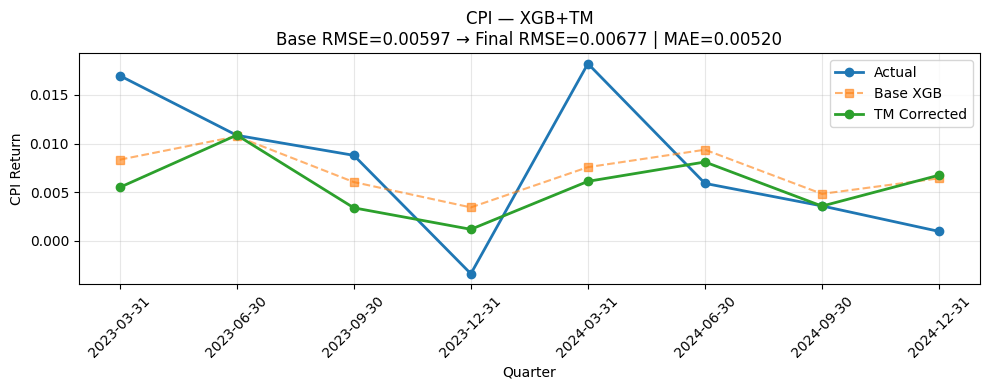

In [ ]:
results, rmse, mae, mape, r2, fi = CPI_prediction(
    df, use_macro=True, model='tsetlin',
    use_scaling=True, feature_selection = False,
    tune=False, shap_binarise=False
)
# {"number_of_clauses": 420, "T": 60, "s": 4.5}

Total: 136 | Train: 128 | Test: 8 | Features: 15

[Optuna Tuning]


  0%|          | 0/50 [00:00<?, ?it/s]

Best: {'number_of_clauses': 407, 'T': 159, 's': 5.72280788469014}  RMSE: 0.0085

XGB+TM
Base RMSE: 0.00557  →  Final RMSE: 0.00554
Date                  Actual    Predicted      Error
-----------------------------------------------------------------
2023-03-31          0.016978     0.008462   0.008516
2023-06-30          0.010843     0.011172   0.000329
2023-09-30          0.008784     0.002956   0.005828
2023-12-31         -0.003388     0.000948   0.004336
2024-03-31          0.018211     0.008872   0.009339
2024-06-30          0.005901     0.008255   0.002354
2024-09-30          0.003584     0.002389   0.001195
2024-12-31          0.000964     0.006092   0.005128
-----------------------------------------------------------------
                                         MAE: 0.00463
                                        RMSE: 0.00554
                                    MAPE (%): 113.00
                                          R²: 0.3793
Inference time: 7884.708 ms


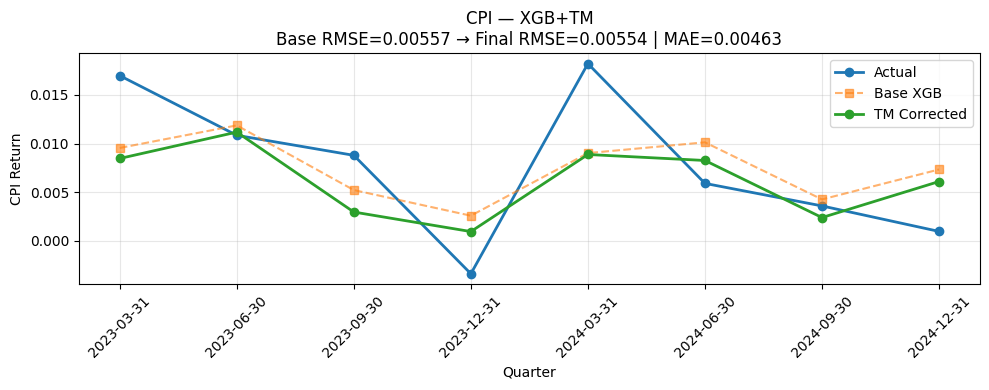

In [ ]:
results, rmse, mae, mape, r2, fi = CPI_prediction(
    df, use_macro=False, model='tsetlin',
    use_scaling=False, tune=True
)
#  {'number_of_clauses': 407, 'T': 159, 's': 5.72280788469014}

### Regresssion TM - shap_binarise

Total: 136 | Train: 128 | Test: 8 | Features: 15

  SHAP-guided bins — min:5 max:30 mean:8.8

XGB+TM + SHAP
Base RMSE: 0.00557  →  Final RMSE: 0.00527
Date                  Actual    Predicted      Error
-----------------------------------------------------------------
2023-03-31          0.016978     0.009220   0.007758
2023-06-30          0.010843     0.013614   0.002771
2023-09-30          0.008784     0.004889   0.003895
2023-12-31         -0.003388     0.002254   0.005642
2024-03-31          0.018211     0.009599   0.008612
2024-06-30          0.005901     0.008500   0.002599
2024-09-30          0.003584     0.003930   0.000346
2024-12-31          0.000964     0.006100   0.005136
-----------------------------------------------------------------
                                         MAE: 0.00459
                                        RMSE: 0.00527
                                    MAPE (%): 114.48
                                          R²: 0.4388
Inference time: 257.848 ms

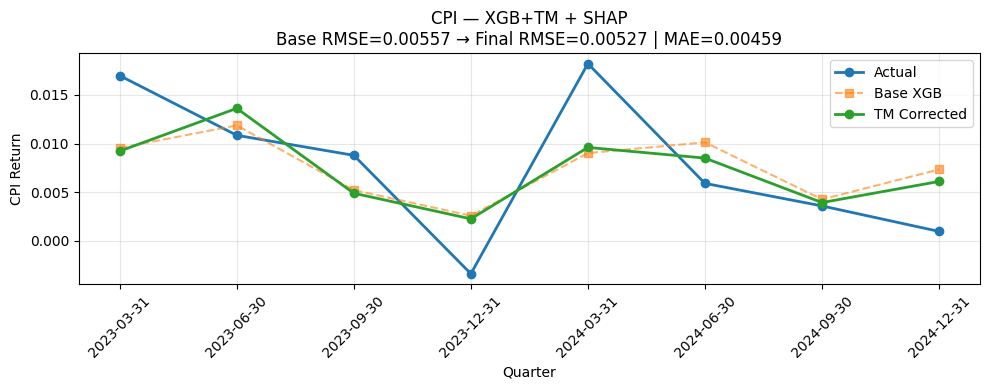

In [ ]:
results, rmse, mae, mape, r2, fi = CPI_prediction(
    df, use_macro=False, model='tsetlin',
    use_scaling=True, tune=False, shap_binarise=True
)
#  {'number_of_clauses': 403, 'T': 96, 's': 4.667245610478635}

Total: 136 | Train: 128 | Test: 8 | Features: 29

  SHAP-guided bins — min:5 max:30 mean:7.1

XGB+TM + SHAP
Base RMSE: 0.00597  →  Final RMSE: 0.00597
Date                  Actual    Predicted      Error
-----------------------------------------------------------------
2023-03-31          0.016978     0.009947   0.007031
2023-06-30          0.010843     0.010731   0.000112
2023-09-30          0.008784     0.008073   0.000711
2023-12-31         -0.003388     0.005702   0.009090
2024-03-31          0.018211     0.009900   0.008311
2024-06-30          0.005901     0.009784   0.003883
2024-09-30          0.003584     0.006661   0.003077
2024-12-31          0.000964     0.008626   0.007662
-----------------------------------------------------------------
                                         MAE: 0.00498
                                        RMSE: 0.00597
                                    MAPE (%): 163.86
                                          R²: 0.2807
Inference time: 235.812 ms

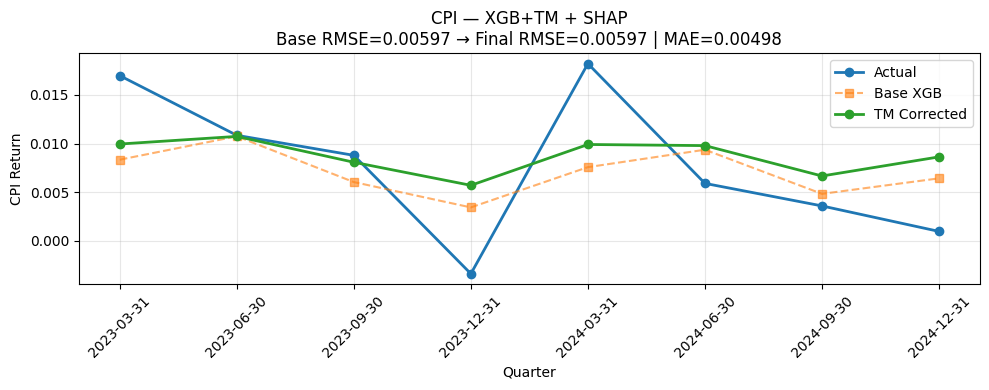

In [ ]:
results, rmse, mae, mape, r2, fi = CPI_prediction(
    df, use_macro=True, model='tsetlin', feature_selection = False,
    use_scaling=True, tune=False, shap_binarise=True
)
# {'number_of_clauses': 250, 'T': 85, 's': 4.5}

Total: 136 | Train: 128 | Test: 8 | Features: 15


Computing SHAP importance for binarisation...

  SHAP-guided bins — min:5 max:20 mean:8.3

Bayes + Tsetlin Residual Corrector  [SHAP-guided bins]
Base R²: 0.4568  →  Final R²: 0.4442
Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2023-03-31              0.02         0.02         0.00
2023-06-30              0.01         0.01         0.00
2023-09-30              0.01         0.01         0.00
2023-12-31             -0.00         0.01         0.01
2024-03-31              0.02         0.01         0.01
2024-06-30              0.01         0.01         0.00
2024-09-30              0.00         0.00         0.00
2024-12-31              0.00         0.00         0.00
-----------------------------------------------------------------
                                         MAE: 0.00399
                                        RMSE: 0.00525
                                    MAPE (%): 92.33
                              

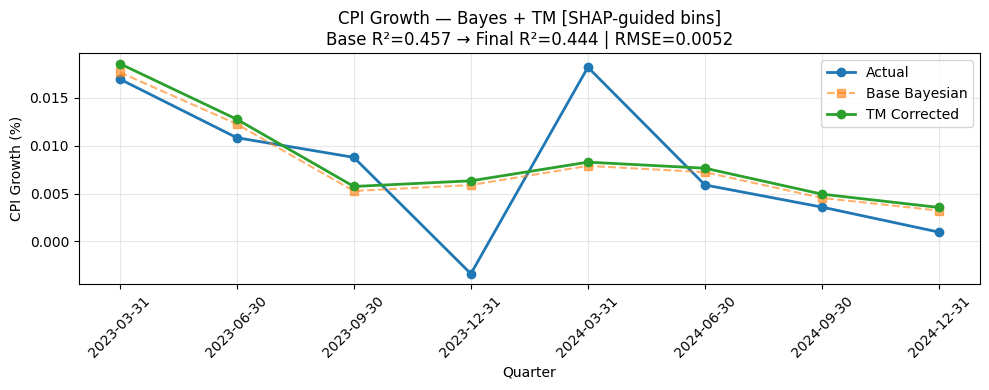

In [ ]:
results, rmse, mae, mape, r2, fi = CPI_prediction(
    df, use_macro=False, model='tsetlin',
    use_scaling=True, tune=False, shap_binarise=True
)


### Regime Based - Regression TM

Total: 136 | Train: 128 | Test: 8 | Features: 29

[Regime Detection]
  HMM regimes — Expansion: 91q | Stress/Recession: 37q
  Features used: ['cpiret_lag1']

[Regime-Conditional TM Training]
  Regime 0 (Expand): 91 quarters

  SHAP-guided bins — min:5 max:30 mean:7.0
  Regime 1 (Stress): 37 quarters

  SHAP-guided bins — min:5 max:30 mean:7.3

  SHAP-guided bins — min:5 max:30 mean:7.1

  SHAP-guided bins — min:5 max:30 mean:7.3

  SHAP-guided bins — min:5 max:30 mean:7.3

  SHAP-guided bins — min:5 max:30 mean:7.3

  SHAP-guided bins — min:5 max:30 mean:7.3

  SHAP-guided bins — min:5 max:30 mean:7.3

  SHAP-guided bins — min:5 max:30 mean:7.3

  SHAP-guided bins — min:5 max:30 mean:7.3

  SHAP-guided bins — min:5 max:30 mean:7.3

  SHAP-guided bins — min:5 max:30 mean:7.0

  SHAP-guided bins — min:5 max:30 mean:7.3

XGB+TM + SHAP + Regime
Base RMSE: 0.00597  →  Final RMSE: 0.00557
Date                  Actual    Predicted      Error   Regime
------------------------------------------

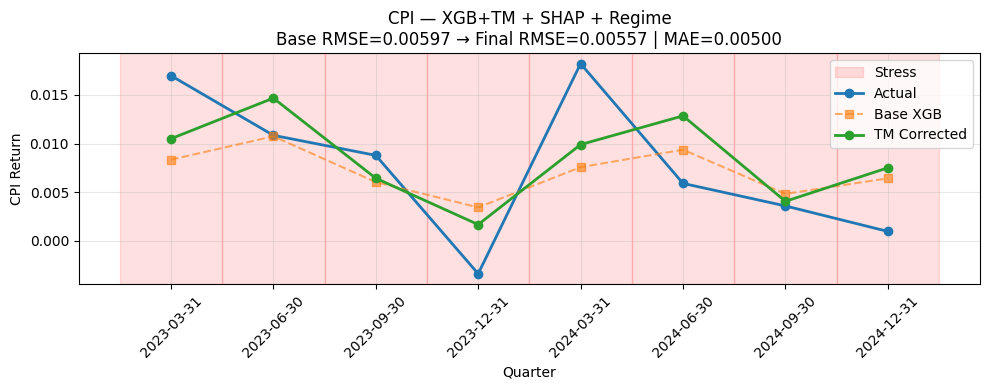

In [ ]:
results, rmse, mae, mape, r2, fi = CPI_prediction(
    df, use_macro=True, model='tsetlin', feature_selection = False,
    use_scaling=True, tune=False, shap_binarise=True, use_regime = True,
)
# {'number_of_clauses': 443, 'T': 83, 's': 4.794330473820019}

Total: 136 | Train: 128 | Test: 8 | Features: 15

[Regime Detection]
  HMM regimes — Expansion: 91q | Stress/Recession: 37q
  Features used: ['cpiret_lag1']

[Regime-Conditional TM Training]
  Regime 0 (Expand): 91 quarters

  SHAP-guided bins — min:5 max:30 mean:8.9
  Regime 1 (Stress): 37 quarters

  SHAP-guided bins — min:5 max:30 mean:9.1

  SHAP-guided bins — min:5 max:30 mean:8.8

  SHAP-guided bins — min:5 max:30 mean:9.1

  SHAP-guided bins — min:5 max:30 mean:9.1

  SHAP-guided bins — min:5 max:30 mean:9.1

  SHAP-guided bins — min:5 max:30 mean:9.1

  SHAP-guided bins — min:5 max:30 mean:9.1

  SHAP-guided bins — min:5 max:30 mean:9.1

  SHAP-guided bins — min:5 max:30 mean:9.1

  SHAP-guided bins — min:5 max:30 mean:9.1

  SHAP-guided bins — min:5 max:30 mean:8.9

  SHAP-guided bins — min:5 max:30 mean:9.1

XGB+TM + SHAP + Regime
Base RMSE: 0.00557  →  Final RMSE: 0.00536
Date                  Actual    Predicted      Error   Regime
------------------------------------------

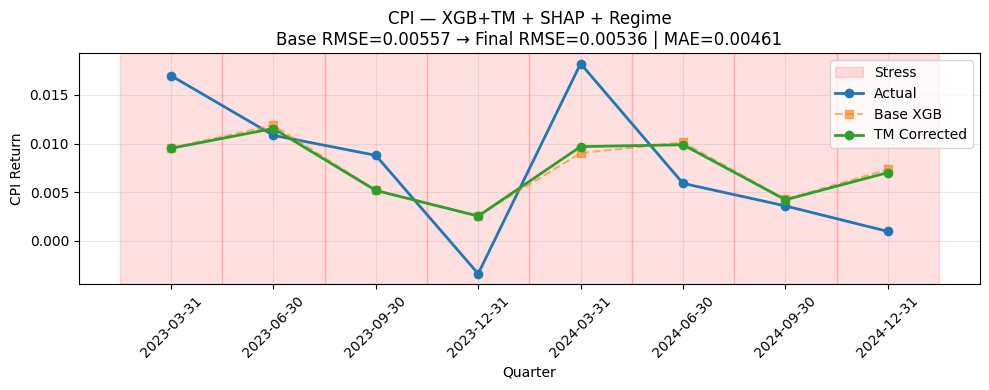

In [ ]:
results, rmse, mae, mape, r2, fi = CPI_prediction(
    df, use_macro=False, model='tsetlin', feature_selection = False,
    use_scaling=True, tune=False, shap_binarise=True, use_regime = True
)
# {'number_of_clauses': 350, 'T': 50, 's': 3.5}

### KNN

Total: 136 | Train: 128 | Test: 8 | Features: 15

Tuning KNN with TimeSeriesSplit (n_iter=30, cv=5)...


/tmp/ipykernel_11768/868908529.py:77: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  study = optuna.create_study(direction="maximize", sampler=TPESampler(seed=42, multivariate=True), pruner=HyperbandPruner())


  0%|          | 0/30 [00:00<?, ?it/s]

[W 2026-07-12 20:06:54,411] Trial 1 failed with parameters: {'n_neighbors': 44, 'weights': 'distance', 'metric': 'manhattan', 'leaf_size': 29} because of the following error: The value nan is not acceptable.
[W 2026-07-12 20:06:54,412] Trial 1 failed with value np.float64(nan).
[W 2026-07-12 20:06:55,509] Trial 4 failed with parameters: {'n_neighbors': 31, 'weights': 'distance', 'metric': 'minkowski', 'leaf_size': 97} because of the following error: The value nan is not acceptable.
[W 2026-07-12 20:06:55,510] Trial 4 failed with value np.float64(nan).
[W 2026-07-12 20:06:55,556] Trial 5 failed with parameters: {'n_neighbors': 41, 'weights': 'uniform', 'metric': 'euclidean', 'leaf_size': 55} because of the following error: The value nan is not acceptable.
[W 2026-07-12 20:06:55,557] Trial 5 failed with value np.float64(nan).
[W 2026-07-12 20:06:55,698] Trial 10 failed with parameters: {'n_neighbors': 39, 'weights': 'uniform', 'metric': 'euclidean', 'leaf_size': 80} because of the follow

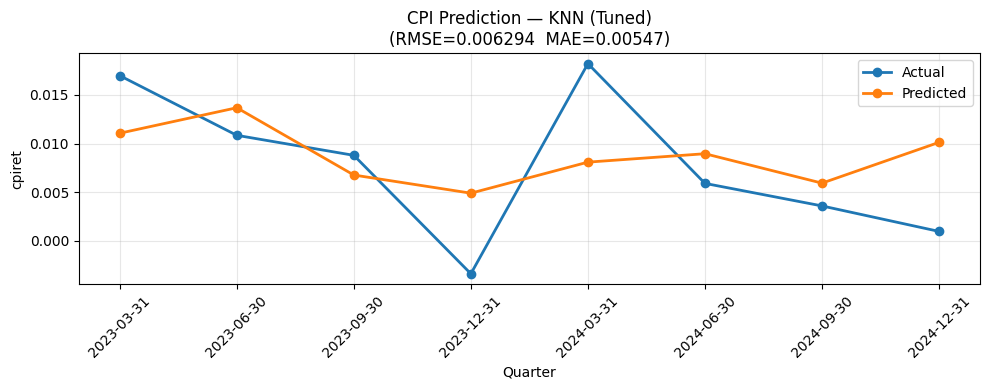

In [ ]:
results, rmse, mae, mape, r2, knn_fi_std, knn_fi_shap, knn_fi_perm, knn_fi_lime = CPI_prediction(
    df, use_macro=False, model='KNN', use_scaling=True,
    importance_strategy=None, tune=True
)

Total: 136 | Train: 128 | Test: 8 | Features: 29

Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2023-03-31          0.016978     0.008775     0.008203
2023-06-30          0.010843     0.007323     0.003520
2023-09-30          0.008784     0.004274     0.004510
2023-12-31         -0.003388     0.005406     0.008794
2024-03-31          0.018211     0.005791     0.012420
2024-06-30          0.005901     0.005080     0.000821
2024-09-30          0.003584     0.003697     0.000113
2024-12-31          0.000964     0.006923     0.005959
-----------------------------------------------------------------
                                        RMSE:     0.006781
                                         MAE:       0.00554
                                    MAPE (%):       136.89
Inference time: 17.076 ms


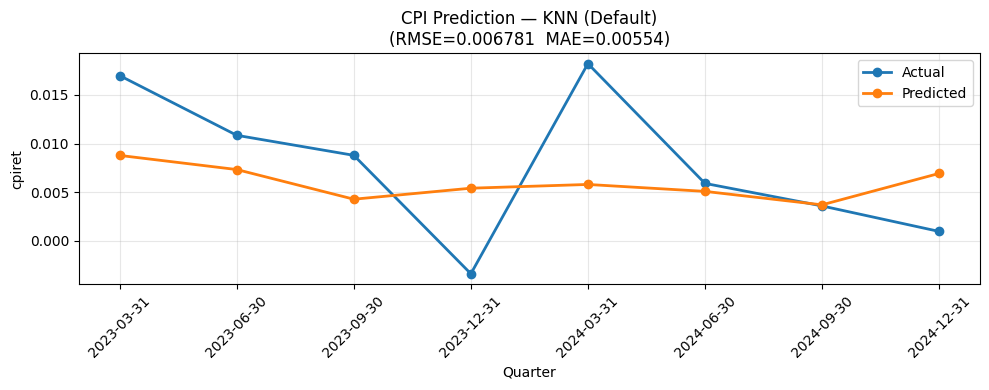

In [ ]:
results, rmse, mape, mae, r2, knn_fi_std, knn_fi_shap, knn_fi_perm, knn_fi_lime = CPI_prediction(
    df, use_macro=True, model='KNN', use_scaling=True,
    feature_selection = False,
    importance_strategy='none', tune=False
)

### SVR

Total: 136 | Train: 128 | Test: 8 | Features: 15

Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2023-03-31          0.016978     0.005300     0.011678
2023-06-30          0.010843     0.009567     0.001276
2023-09-30          0.008784     0.005844     0.002940
2023-12-31         -0.003388     0.002735     0.006123
2024-03-31          0.018211     0.006184     0.012027
2024-06-30          0.005901     0.006143     0.000242
2024-09-30          0.003584     0.004550     0.000966
2024-12-31          0.000964     0.008520     0.007556
-----------------------------------------------------------------
                                        RMSE:     0.006954
                                         MAE:       0.00535
                                    MAPE (%):       146.96
Inference time: 16.132 ms


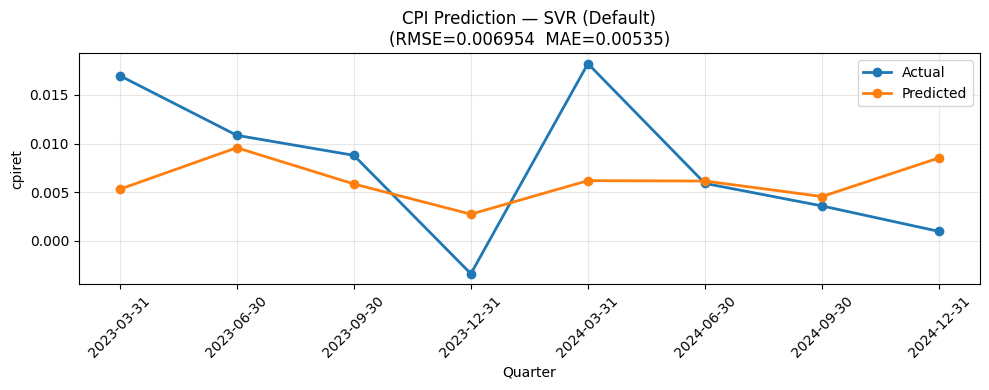

  0%|          | 0/128 [00:00<?, ?it/s]

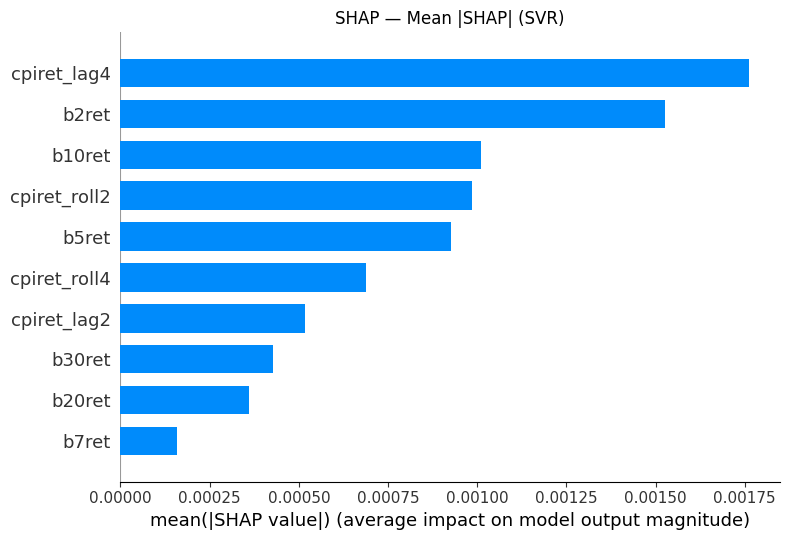

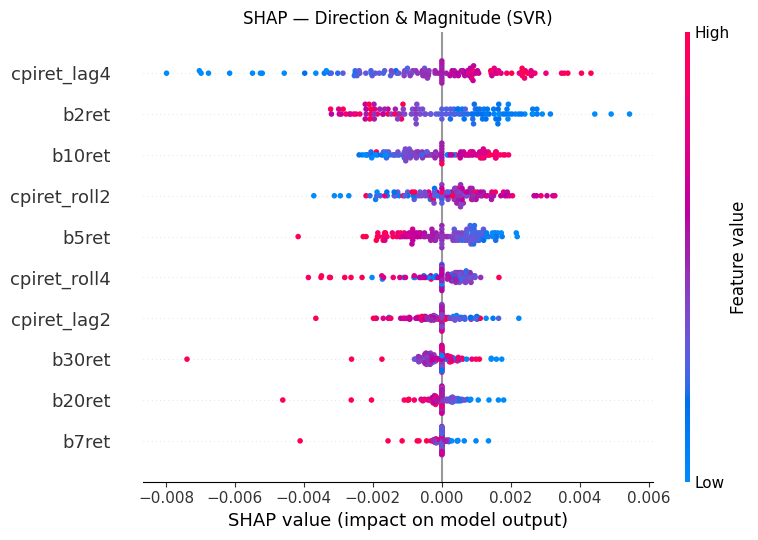

In [ ]:
results, rmse, mae, mape, r2, svr_fi_std, svr_fi_shap, svr_fi_perm, svr_fi_lime = CPI_prediction(
    df, use_macro=False, model='SVR', use_scaling=True,
    importance_strategy='shap', tune=False
)

Total: 136 | Train: 128 | Test: 8 | Features: 29

Tuning SVR with TimeSeriesSplit (n_iter=30, cv=5)...


/tmp/ipykernel_11768/868908529.py:77: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  study = optuna.create_study(direction="maximize", sampler=TPESampler(seed=42, multivariate=True), pruner=HyperbandPruner())


  0%|          | 0/30 [00:00<?, ?it/s]

Best CV R²: 0.067168
Best params: {'C': 0.047292993344844936, 'epsilon': 0.003704674944676552, 'gamma': 'auto', 'kernel': 'rbf'}

Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2023-03-31          0.016978     0.011546     0.005432
2023-06-30          0.010843     0.018562     0.007719
2023-09-30          0.008784     0.009617     0.000833
2023-12-31         -0.003388    -0.002026     0.001362
2024-03-31          0.018211     0.008561     0.009650
2024-06-30          0.005901     0.015093     0.009192
2024-09-30          0.003584     0.004914     0.001330
2024-12-31          0.000964     0.006994     0.006030
-----------------------------------------------------------------
                                        RMSE:     0.006199
                                         MAE:       0.00519
                                    MAPE (%):       128.03
Inference time: 15.676 ms


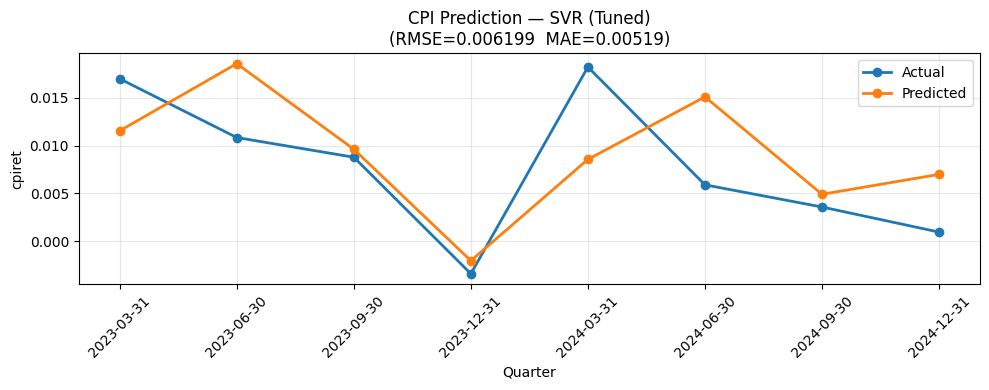

In [ ]:
results, rmse, mae, mape, r2, svr_fi_std, svr_fi_shap, svr_fi_perm, svr_fi_lime = CPI_prediction(
    df, use_macro=True, model='SVR', use_scaling=True,
    importance_strategy='none', tune=True
)

### GB

Total: 136 | Train: 128 | Test: 8 | Features: 15

Tuning GB with TimeSeriesSplit (n_iter=30, cv=5)...


/tmp/ipykernel_11768/868908529.py:77: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  study = optuna.create_study(direction="maximize", sampler=TPESampler(seed=42, multivariate=True), pruner=HyperbandPruner())


  0%|          | 0/30 [00:00<?, ?it/s]

Best CV R²: 0.076724
Best params: {'n_estimators': 1010, 'learning_rate': 0.0033717700999439603, 'max_depth': 3, 'subsample': 0.6218312046432304, 'min_samples_leaf': 4}

Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2023-03-31          0.016978     0.012186     0.004792
2023-06-30          0.010843     0.021268     0.010425
2023-09-30          0.008784     0.004533     0.004251
2023-12-31         -0.003388    -0.007754     0.004366
2024-03-31          0.018211     0.010956     0.007255
2024-06-30          0.005901     0.013590     0.007689
2024-09-30          0.003584     0.004536     0.000952
2024-12-31          0.000964     0.004669     0.003705
-----------------------------------------------------------------
                                        RMSE:     0.006074
                                         MAE:       0.00543
                                    MAPE (%):       110.34
Inference time: 22.988 ms

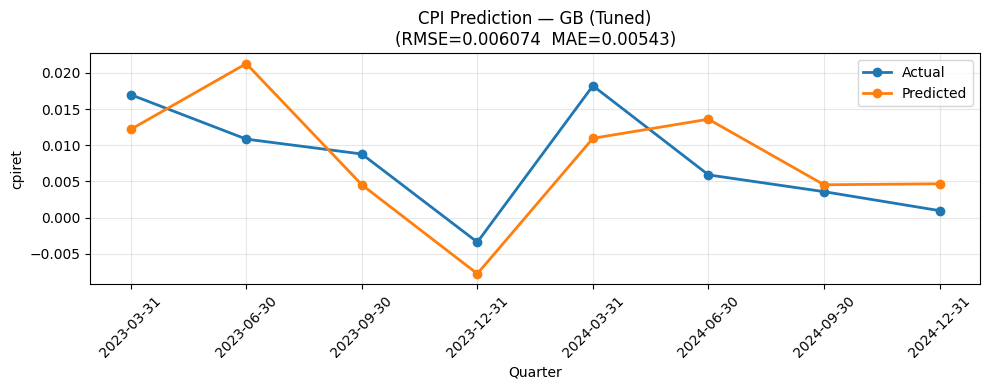

In [ ]:
results, rmse, mae, mape, r2, gb_fi_std, gb_fi_shap, gb_fi_perm, gb_fi_lime = CPI_prediction(
    df, use_macro=False, model='GB', use_scaling=True,
    importance_strategy=None, tune=True
)
# {'n_estimators': 1010, 'learning_rate': 0.0033717700999439603, 'max_depth': 3, 'subsample': 0.6218312046432304, 'min_samples_leaf': 4}

Total: 136 | Train: 128 | Test: 8 | Features: 29

Tuning GB with TimeSeriesSplit (n_iter=30, cv=5)...


/tmp/ipykernel_5143/868908529.py:77: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  study = optuna.create_study(direction="maximize", sampler=TPESampler(seed=42, multivariate=True), pruner=HyperbandPruner())


  0%|          | 0/30 [00:00<?, ?it/s]

Best CV R²: 0.008102
Best params: {'n_estimators': 191, 'learning_rate': 0.0037969028093798305, 'max_depth': 5, 'subsample': 0.7790037173325489, 'min_samples_leaf': 12}

Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2023-03-31          0.016978     0.007802     0.009176
2023-06-30          0.010843     0.010669     0.000174
2023-09-30          0.008784     0.005077     0.003707
2023-12-31         -0.003388     0.004302     0.007690
2024-03-31          0.018211     0.005916     0.012295
2024-06-30          0.005901     0.007263     0.001362
2024-09-30          0.003584     0.004426     0.000842
2024-12-31          0.000964     0.007041     0.006077
-----------------------------------------------------------------
                                        RMSE:     0.006593
                                         MAE:       0.00517
                                    MAPE (%):       133.66
Inference time: 16.943 ms

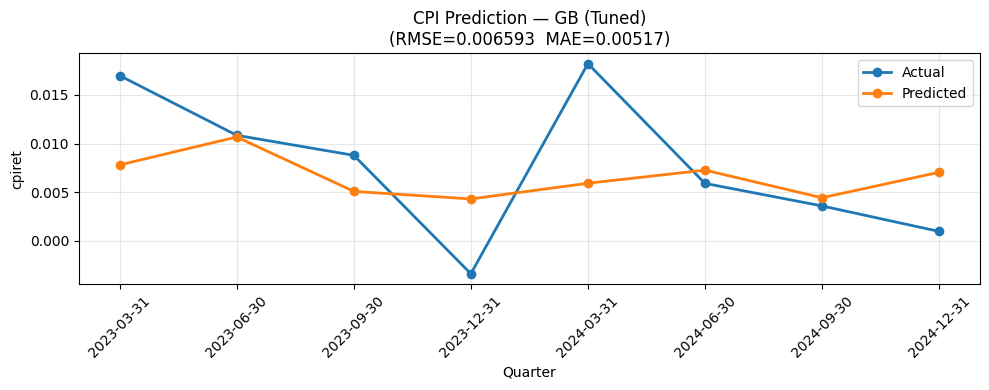

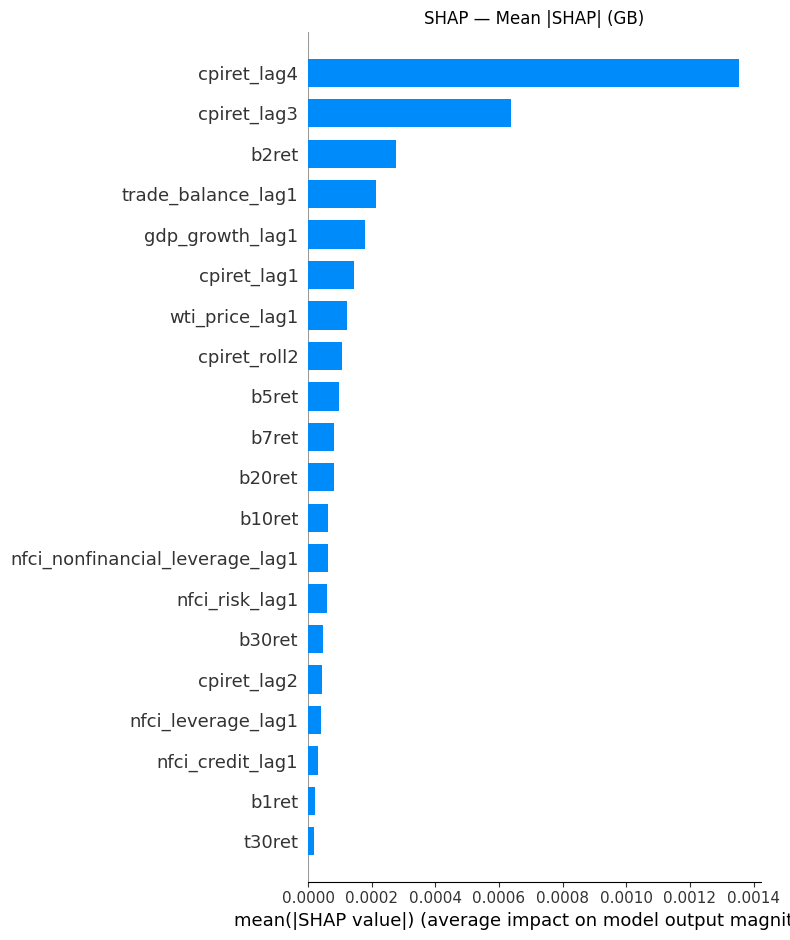

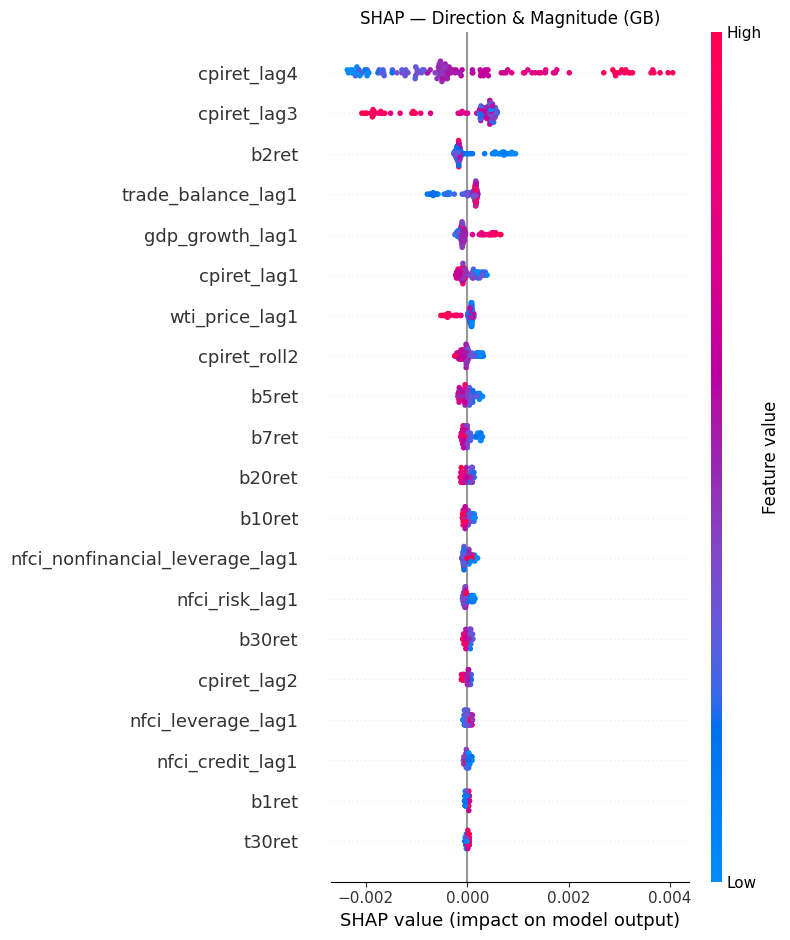

In [ ]:
results, rmse, mae, mape, r2, gb_fi_std, gb_fi_shap, gb_fi_perm, gb_fi_lime = CPI_prediction(
    df, use_macro=True, model='GB', use_scaling=True, feature_selection=False,
    importance_strategy='shap', tune=True
)

### XGB

Total: 136 | Train: 128 | Test: 8 | Features: 15

Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2023-03-31          0.016978     0.009545     0.007433
2023-06-30          0.010843     0.011864     0.001021
2023-09-30          0.008784     0.005213     0.003571
2023-12-31         -0.003388     0.002535     0.005923
2024-03-31          0.018211     0.008720     0.009491
2024-06-30          0.005901     0.010121     0.004220
2024-09-30          0.003584     0.004255     0.000671
2024-12-31          0.000964     0.007332     0.006368
-----------------------------------------------------------------
                                        RMSE:     0.005624
                                         MAE:       0.00484
                                    MAPE (%):       133.95
Inference time: 108.105 ms


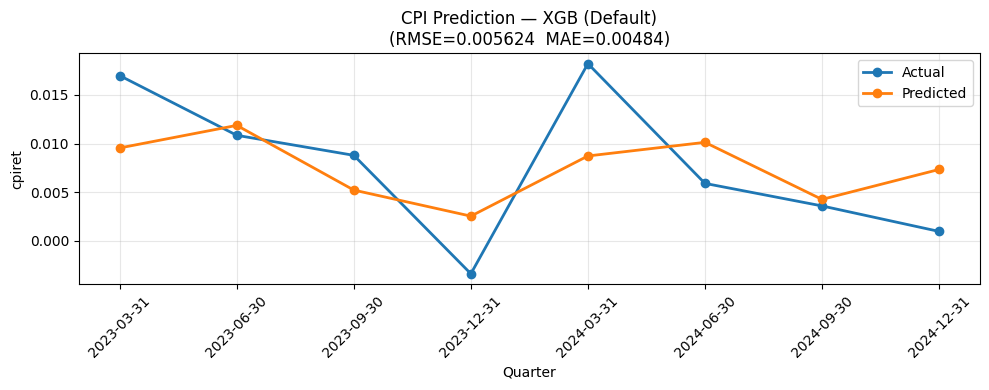

In [ ]:
results, rmse, mae, mape, r2, xgb_fi_std, xgb_fi_shap, xgb_fi_perm, xgb_fi_lime = CPI_prediction(
    df, use_macro=False, model='XGB', use_scaling=True,
    importance_strategy=None, tune=False
)

Total: 136 | Train: 128 | Test: 8 | Features: 29

Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2023-03-31          0.016978     0.008338     0.008640
2023-06-30          0.010843     0.010737     0.000106
2023-09-30          0.008784     0.006002     0.002782
2023-12-31         -0.003388     0.004578     0.007966
2024-03-31          0.018211     0.007201     0.011010
2024-06-30          0.005901     0.009398     0.003497
2024-09-30          0.003584     0.004825     0.001241
2024-12-31          0.000964     0.008255     0.007291
-----------------------------------------------------------------
                                        RMSE:     0.006461
                                         MAE:       0.00532
                                    MAPE (%):       153.66
Inference time: 20.259 ms


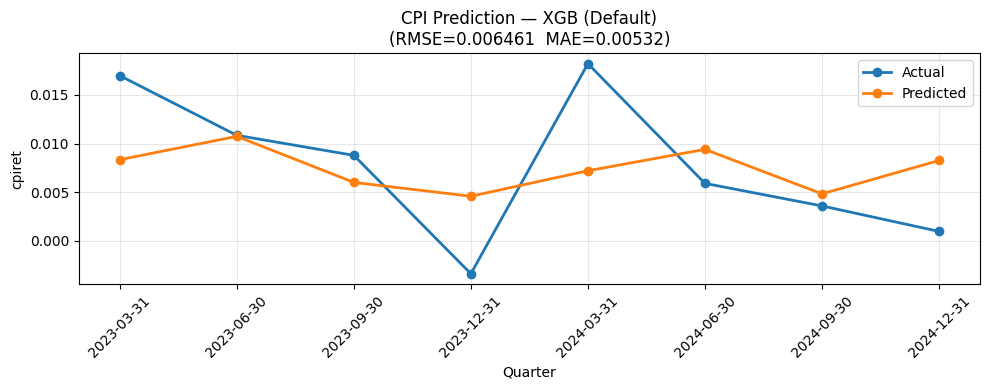

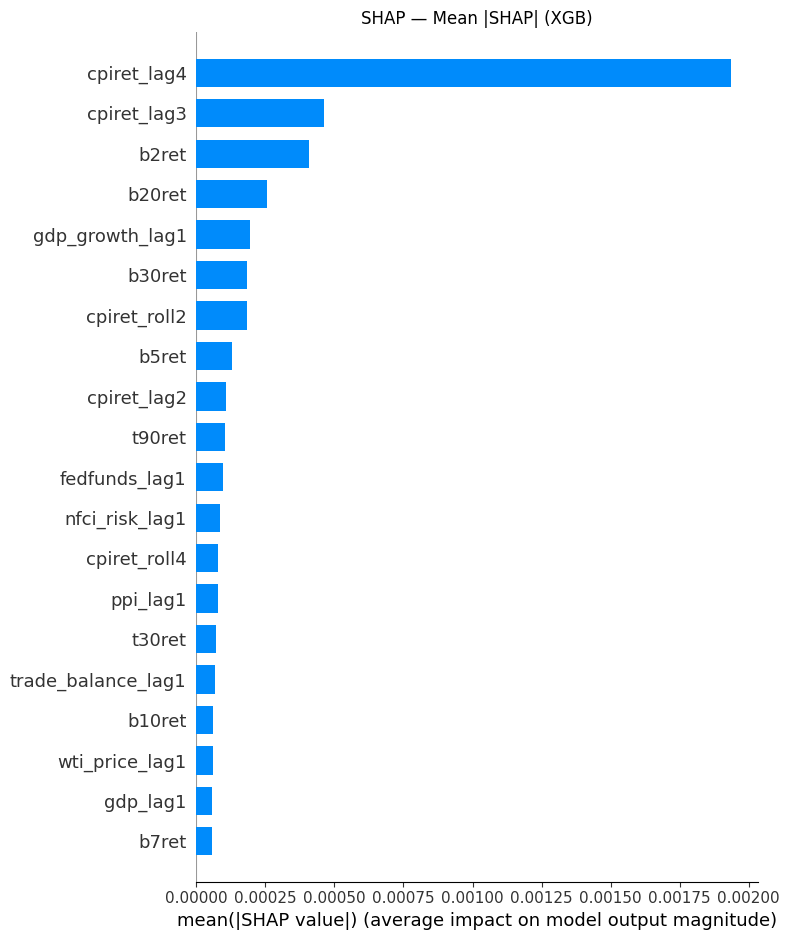

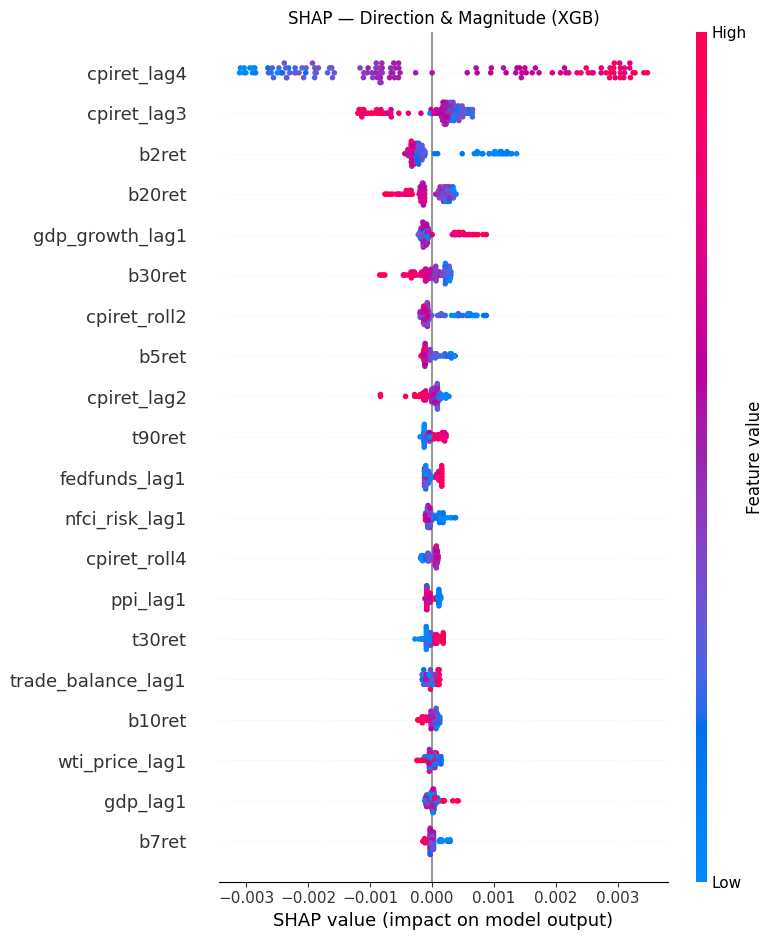

In [ ]:
results, rmse, mape, mae, r2, xgb_fi_std, xgb_fi_shap, xgb_fi_perm, xgb_fi_lime = CPI_prediction(
    df, use_macro=True, model='XGB', use_scaling=True, feature_selection=False,
    importance_strategy='shap', tune=False
)

### Catboost

Total: 136 | Train: 128 | Test: 8 | Features: 15

Tuning catboost with TimeSeriesSplit (n_iter=30, cv=5)...


/tmp/ipykernel_11768/868908529.py:77: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  study = optuna.create_study(direction="maximize", sampler=TPESampler(seed=42, multivariate=True), pruner=HyperbandPruner())


  0%|          | 0/30 [00:00<?, ?it/s]

Best CV R²: 0.088612
Best params: {'iterations': 1328, 'learning_rate': 0.013395470089715915, 'depth': 12, 'l2_leaf_reg': 0.008275698261091992, 'subsample': 0.6833230751138639}

Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2023-03-31          0.016978     0.010309     0.006669
2023-06-30          0.010843     0.015591     0.004748
2023-09-30          0.008784     0.005839     0.002945
2023-12-31         -0.003388     0.004409     0.007797
2024-03-31          0.018211     0.009694     0.008517
2024-06-30          0.005901     0.009504     0.003603
2024-09-30          0.003584     0.004124     0.000540
2024-12-31          0.000964     0.009072     0.008108
-----------------------------------------------------------------
                                        RMSE:     0.006000
                                         MAE:       0.00537
                                    MAPE (%):       163.83
Inference time: 2

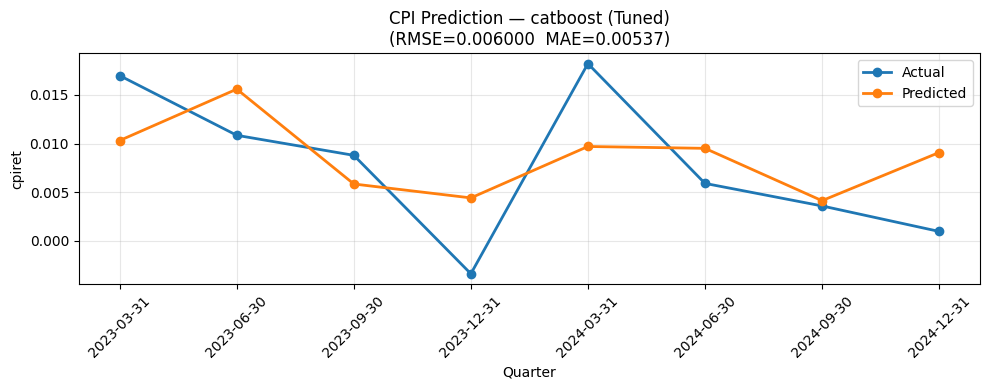

In [ ]:
results, rmse, mae, mape, r2, catboost_fi_std, catboost_fi_shap, catboost_fi_perm, catboost_f1_lime = CPI_prediction(
    df, use_macro=False, model='catboost', use_scaling=True,
    importance_strategy='none', tune=True
)

Total: 136 | Train: 128 | Test: 8 | Features: 29

Tuning catboost with TimeSeriesSplit (n_iter=30, cv=5)...


/tmp/ipykernel_11768/868908529.py:77: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  study = optuna.create_study(direction="maximize", sampler=TPESampler(seed=42, multivariate=True), pruner=HyperbandPruner())


  0%|          | 0/30 [00:00<?, ?it/s]

Best CV R²: 0.055395
Best params: {'iterations': 2670, 'learning_rate': 0.03029966378802015, 'depth': 11, 'l2_leaf_reg': 0.0013103591476027545, 'subsample': 0.7445200317845103}

Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2023-03-31          0.016978     0.009848     0.007130
2023-06-30          0.010843     0.015586     0.004743
2023-09-30          0.008784     0.006760     0.002024
2023-12-31         -0.003388     0.004380     0.007768
2024-03-31          0.018211     0.008892     0.009319
2024-06-30          0.005901     0.010544     0.004643
2024-09-30          0.003584     0.004188     0.000604
2024-12-31          0.000964     0.008938     0.007974
-----------------------------------------------------------------
                                        RMSE:     0.006226
                                         MAE:       0.00553
                                    MAPE (%):       163.99
Inference time: 2

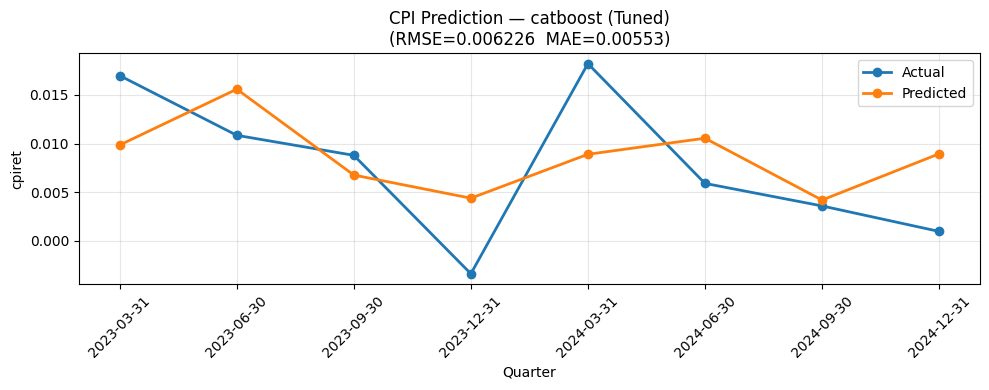

In [ ]:
results, rmse, mape, mae, r2, catboost_fi_std, catboost_fi_shap, catboost_fi_perm, catboost_fi_lime = CPI_prediction(
    df, use_macro=True, model='catboost', use_scaling=True, feature_selection=True,
    importance_strategy='none', tune=True
)
# {'iterations': 2670, 'learning_rate': 0.03029966378802015, 'depth': 11, 'l2_leaf_reg': 0.0013103591476027545, 'subsample': 0.7445200317845103}

### bayes

Total: 136 | Train: 128 | Test: 8 | Features: 15

Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2023-03-31          0.016978     0.014161     0.002817
2023-06-30          0.010843     0.021573     0.010730
2023-09-30          0.008784     0.011683     0.002899
2023-12-31         -0.003388    -0.001288     0.002100
2024-03-31          0.018211     0.011579     0.006632
2024-06-30          0.005901     0.015660     0.009759
2024-09-30          0.003584     0.005491     0.001907
2024-12-31          0.000964     0.006861     0.005897
-----------------------------------------------------------------
                                        RMSE:     0.006260
                                         MAE:       0.00534
                                    MAPE (%):       134.65
Inference time: 13.004 ms


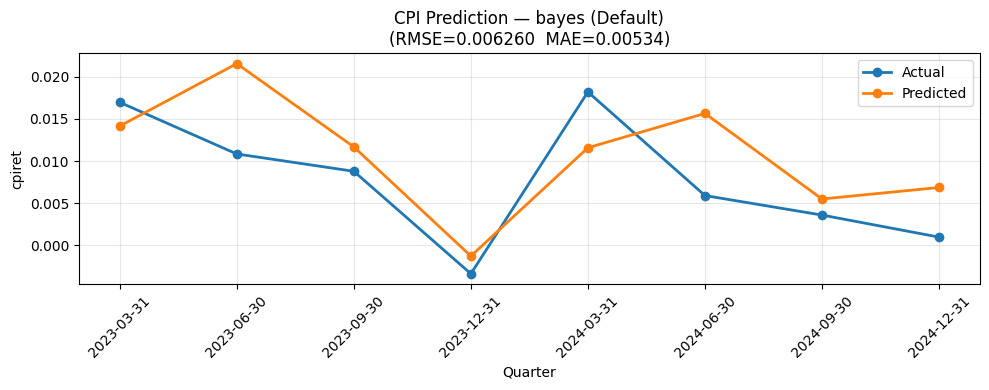

In [ ]:
results, rmse, mae, mape, r2, bayes_fi_std, bayes_fi_shap, bayes_fi_perm, bayes_f1_lime = CPI_prediction(
    df, use_macro=False, model='bayes',
    use_scaling=True,
    feature_selection=False,
    importance_strategy=None,
    tune=False
)

Total: 136 | Train: 128 | Test: 8 | Features: 29

Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2023-03-31          0.016978     0.014751     0.002227
2023-06-30          0.010843     0.020885     0.010042
2023-09-30          0.008784     0.007955     0.000829
2023-12-31         -0.003388    -0.002880     0.000508
2024-03-31          0.018211     0.011583     0.006628
2024-06-30          0.005901     0.014888     0.008987
2024-09-30          0.003584     0.003449     0.000135
2024-12-31          0.000964     0.005489     0.004525
-----------------------------------------------------------------
                                        RMSE:     0.005612
                                         MAE:       0.00424
                                    MAPE (%):        99.00
Inference time: 14.641 ms


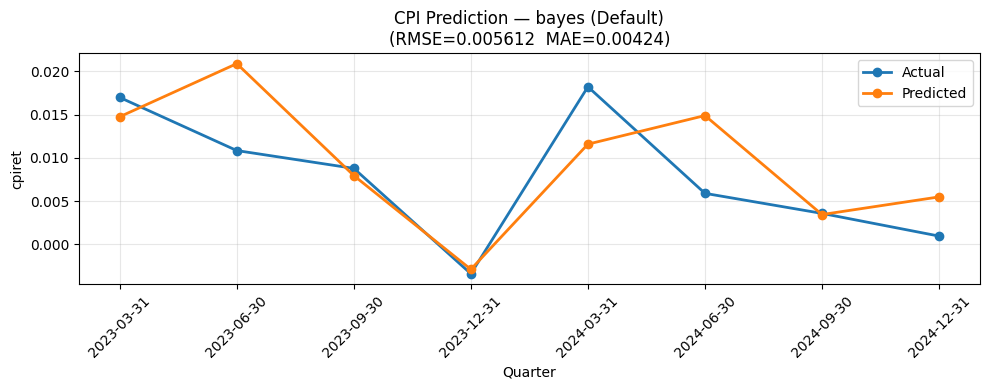

  0%|          | 0/128 [00:00<?, ?it/s]

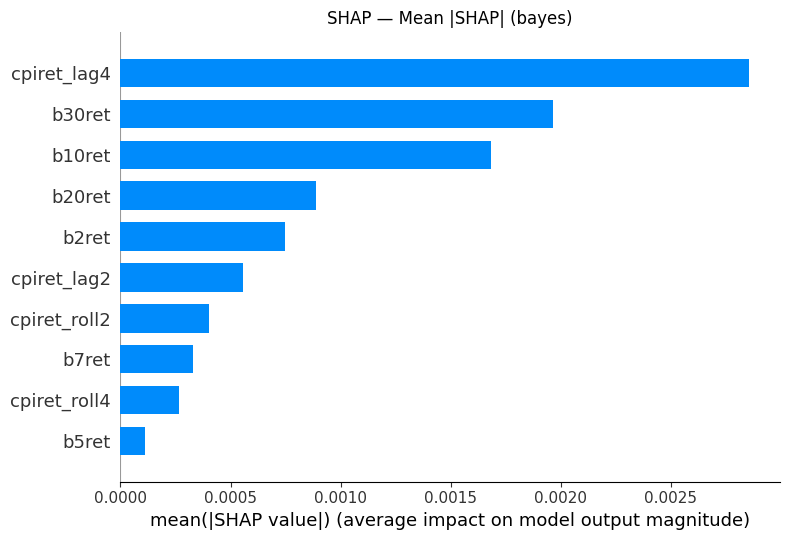

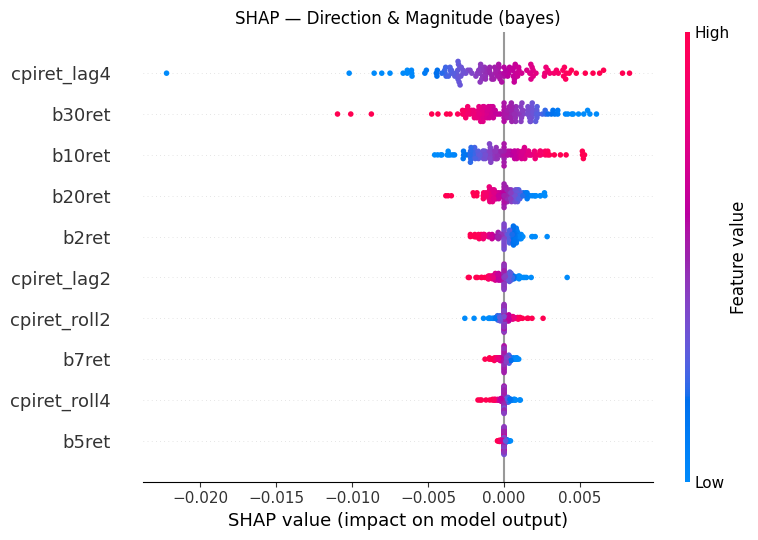

In [ ]:
results, rmse, mae, mape, r2, bayes_fi_std, bayes_fi_shap, bayes_fi_perm, bayes_f1_lime = CPI_prediction(
    df, use_macro=True, model='bayes',
    use_scaling=True,
    feature_selection=True,
    importance_strategy='shap',
    tune=False
)

### Arima

Total: 136 | Train: 128 | Test: 8 | Features: 15

ARIMA — Best AIC: -828.34
Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2023-03-31          0.016978     0.018823     0.001845
2023-06-30          0.010843     0.019663     0.008820
2023-09-30          0.008784     0.001063     0.007721
2023-12-31         -0.003388    -0.000027     0.003361
2024-03-31          0.018211     0.012195     0.006016
2024-06-30          0.005901     0.012739     0.006838
2024-09-30          0.003584     0.000689     0.002895
2024-12-31          0.000964    -0.000018     0.000982
-----------------------------------------------------------------
                                        RMSE:     0.005527
                                         MAE:        0.0048
Inference time: 2.286 ms

Note: ARIMA coefficients:
ar.L1      0.131327
ar.S.L4    0.647876
sigma2     0.000066
dtype: float64


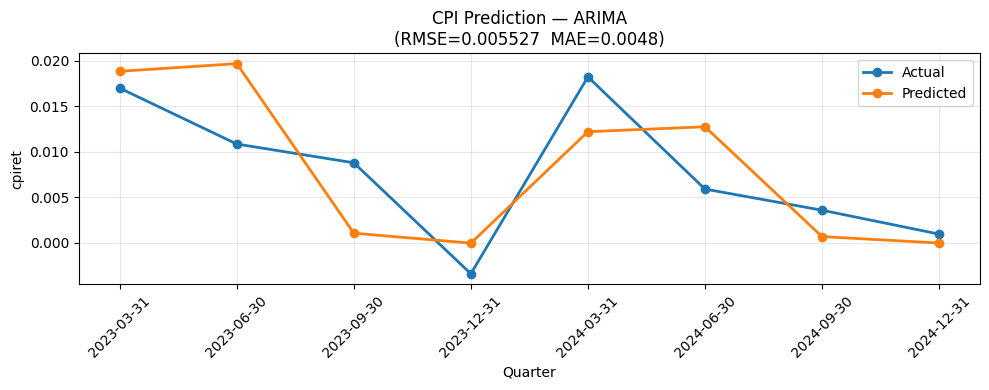

In [ ]:
results, rmse, mae, mape, r2 = CPI_prediction(
    df, use_macro=False, model='arima',
    use_scaling=True,
    feature_selection=False,
    importance_strategy='shap',
    tune=True, n_iter=30, cv_splits=5
)

Total: 136 | Train: 128 | Test: 8 | Features: 29


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood op


ARIMA — Best AIC: -821.24
Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2023-03-31          0.016978     0.019128     0.002150
2023-06-30          0.010843     0.022863     0.012020
2023-09-30          0.008784     0.007129     0.001655
2023-12-31         -0.003388     0.006048     0.009436
2024-03-31          0.018211     0.014175     0.004036
2024-06-30          0.005901     0.015442     0.009541
2024-09-30          0.003584     0.008670     0.005086
2024-12-31          0.000964     0.009893     0.008929
-----------------------------------------------------------------
                                        RMSE:     0.007532
                                         MAE:        0.0066
Inference time: 3.529 ms

Note: ARIMA coefficients:
cpiret_lag1                       -2.899459e-02
wti_price_lag1                    -2.987417e-04
fedfunds_lag1                      4.594030e-05
nfci_lag1                      

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


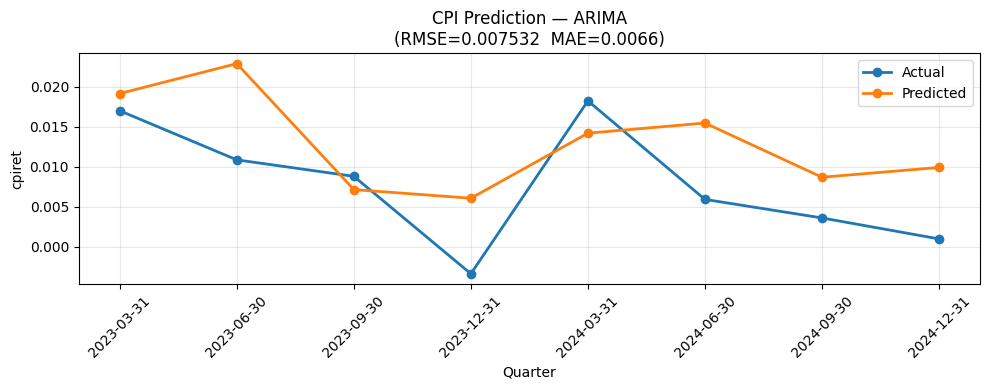

In [ ]:
results, rmse, mae, mape, r2 = CPI_prediction(
    df, use_macro=True, model='arima',
    use_scaling=True,
    feature_selection=True,
    importance_strategy=False, n_iter=30, cv_splits=5
)

## Aggregate feature importance

In [ ]:
def _classify(feature: str) -> str:
    base = feature.replace("_lag1", "").replace("_lag2", "").replace("_lag4", "")
    return "macro" if base in macro_vars else "micro"

In [ ]:

def _build_matrices(importance_results: dict):
    model_names  = list(importance_results.keys())
    n_models     = len(model_names)

    all_features = sorted(
        set(f for fi in importance_results.values() for f in fi['feature'])
    )
    n_features = len(all_features)

    rank_matrix  = pd.DataFrame(index=all_features, columns=model_names, dtype=float)
    score_matrix = pd.DataFrame(index=all_features, columns=model_names, dtype=float)

    for model_name, fi_df in importance_results.items():
        fi_df = fi_df.copy().reset_index(drop=True)
        fi_df['rank'] = fi_df['importance'].rank(ascending=False, method='min')

        imp_min = fi_df['importance'].min()
        imp_max = fi_df['importance'].max()
        denom   = imp_max - imp_min if imp_max != imp_min else 1.0
        fi_df['norm_score'] = (fi_df['importance'] - imp_min) / denom

        for _, row in fi_df.iterrows():
            rank_matrix.loc[row['feature'],  model_name] = row['rank']
            score_matrix.loc[row['feature'], model_name] = row['norm_score']

        for f in set(all_features) - set(fi_df['feature']):
            rank_matrix.loc[f,  model_name] = n_features + 1
            score_matrix.loc[f, model_name] = 0.0

    return model_names, all_features, n_features, rank_matrix, score_matrix

In [ ]:
# importance_results = {
#     'XGB':      xgb_fi_shap,
#     'GB':       gb_fi_shap,
#     'bayes':    bayes_fi_shap,
#     'catboost': catboost_fi_shap,
#     'knn': knn_fi_shap,
# }

#### save and load importance results

In [ ]:
# for model_name, df in importance_results.items():
#     df.to_csv(f"/content/drive/MyDrive/Forecasting-Agent-for-Fintech/data/{model_name}_shap_importance_CPI.csv", index=False)

In [ ]:
import glob
import os
import pandas as pd

importance_results = {}

for file in glob.glob(os.path.join("/content/drive/MyDrive/Forecasting-Agent-for-Fintech/data", "*_lime_importance_CPI.csv")): # and also load files that end with _shap_importance_cpi
    model_name = os.path.basename(file).replace("_lime_importance_GDP.csv", "")
    importance_results[model_name] = pd.read_csv(file)

# Check what was loaded
print(importance_results.keys())

dict_keys(['XGB_lime_importance_CPI.csv', 'GB_lime_importance_CPI.csv', 'bayes_lime_importance_CPI.csv', 'catboost_lime_importance_CPI.csv', 'knn_lime_importance_CPI.csv'])


In [ ]:
macro_vars = [
        "wti_price","fedfunds","nfci","anfci","nfci_risk","nfci_credit",
        "nfci_leverage","nfci_nonfinancial_leverage","gdp","gdp_growth","ppi",
        "trade_balance","unrate","usd_index"
    ]

#### plotting


>>> LIME — CPI: ['XGB', 'GB', 'bayes', 'catboost', 'knn']

MODEL AGREEMENT — Top 15 features per model
  cpiret_lag4                    █████      5/5 (100%)  [micro]
  b2ret                          █████      5/5 (100%)  [micro]
  b20ret                         █████      5/5 (100%)  [micro]
  b7ret                          █████      5/5 (100%)  [micro]
  cpiret_roll2                   █████      5/5 (100%)  [micro]
  b5ret                          █████      5/5 (100%)  [micro]
  cpiret_lag2                    ████       4/5 (80%)  [micro]
  b10ret                         ████       4/5 (80%)  [micro]
  b30ret                         ████       4/5 (80%)  [micro]
  cpiret_roll4                   ████       4/5 (80%)  [micro]
  cpiret_lag3                    █          1/5 (20%)  [micro]
  wti_price_lag1                 █          1/5 (20%)  [macro]
  trade_balance_lag1             █          1/5 (20%)  [macro]
  gdp_lag1                       █          1/5 (20%)  [macro]
  gdp_gr

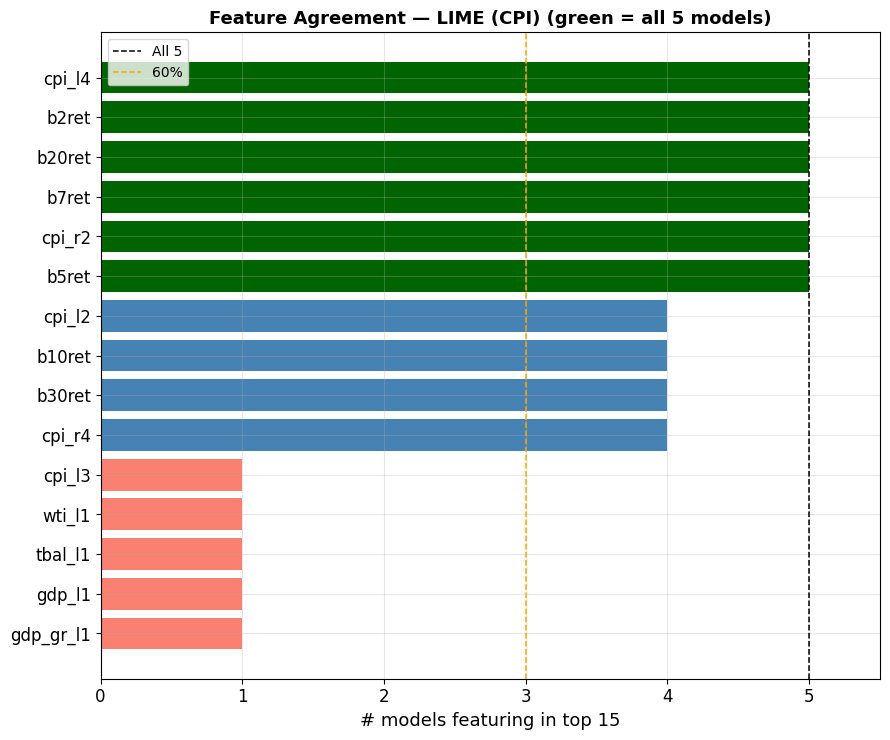


>>> SHAP — CPI: ['XGB', 'GB', 'bayes', 'catboost', 'knn']

MODEL AGREEMENT — Top 15 features per model
  cpiret_lag4                    █████      5/5 (100%)  [micro]
  b2ret                          █████      5/5 (100%)  [micro]
  cpiret_roll2                   █████      5/5 (100%)  [micro]
  b7ret                          █████      5/5 (100%)  [micro]
  b20ret                         █████      5/5 (100%)  [micro]
  b5ret                          █████      5/5 (100%)  [micro]
  cpiret_lag2                    ████       4/5 (80%)  [micro]
  b30ret                         ████       4/5 (80%)  [micro]
  cpiret_roll4                   ████       4/5 (80%)  [micro]
  b10ret                         ████       4/5 (80%)  [micro]
  cpiret_lag3                    █          1/5 (20%)  [micro]
  wti_price_lag1                 █          1/5 (20%)  [macro]
  trade_balance_lag1             █          1/5 (20%)  [macro]
  b1ret                          █          1/5 (20%)  [micro]
  gdp_gr

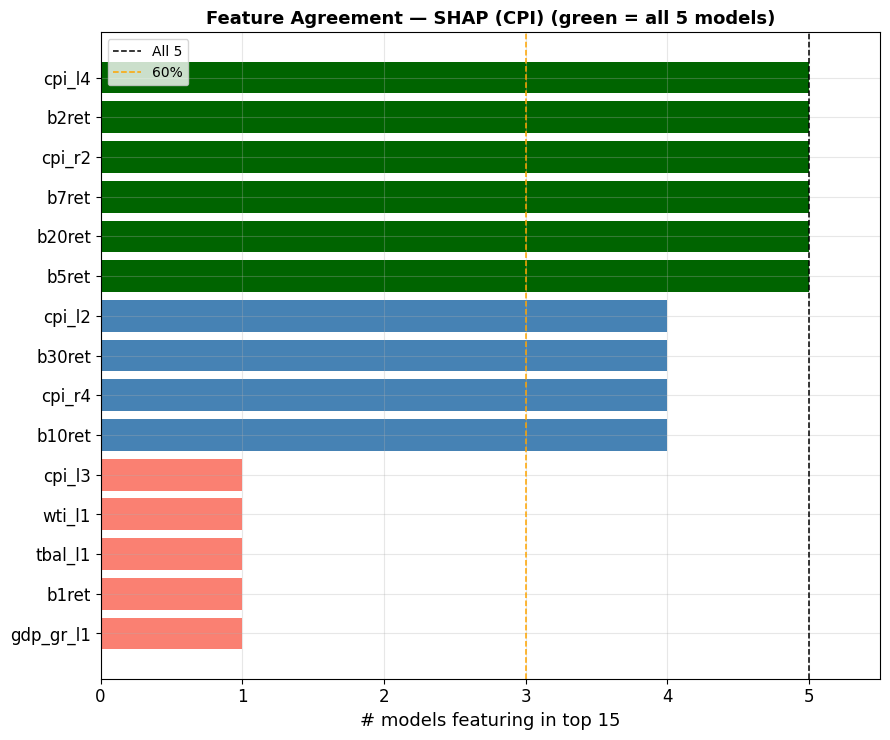

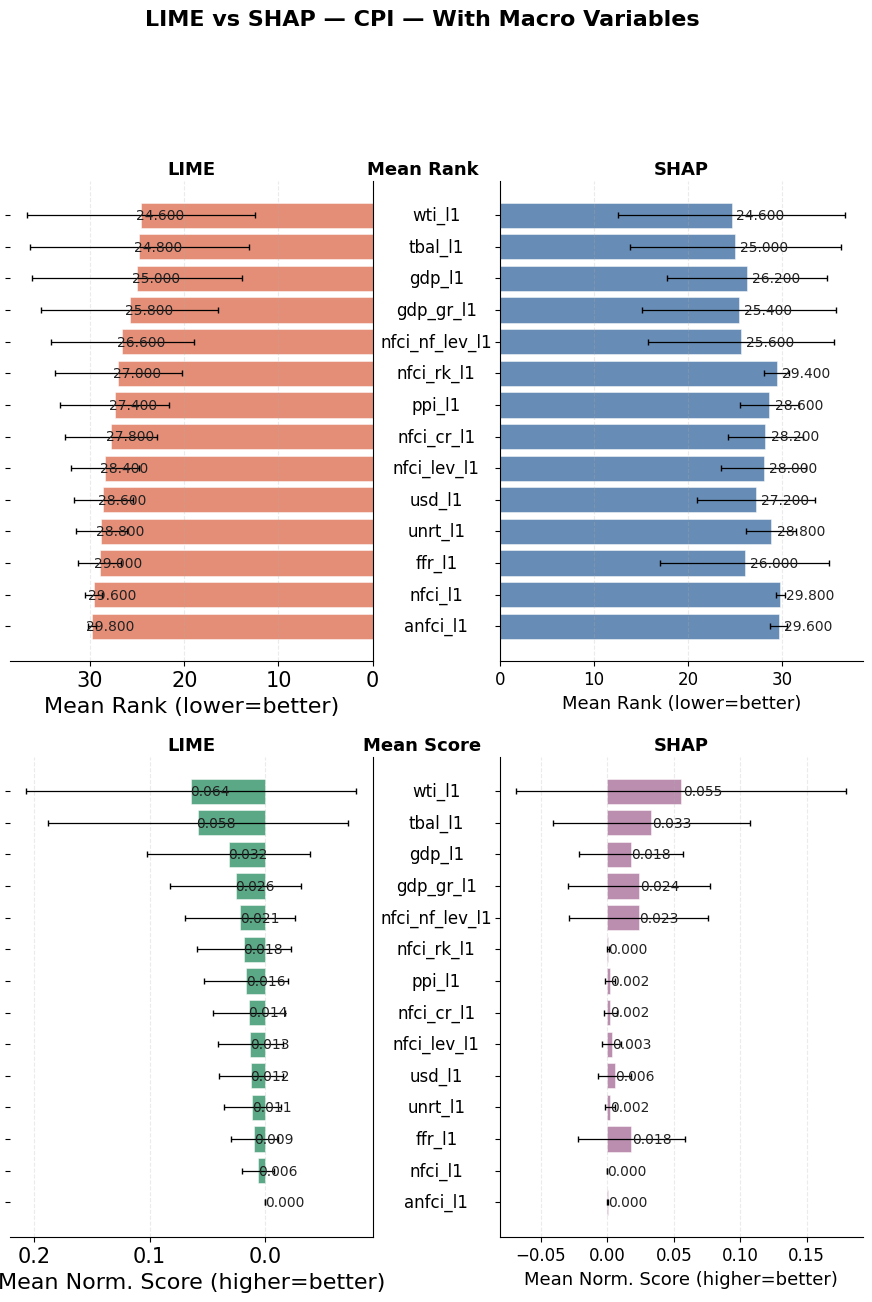

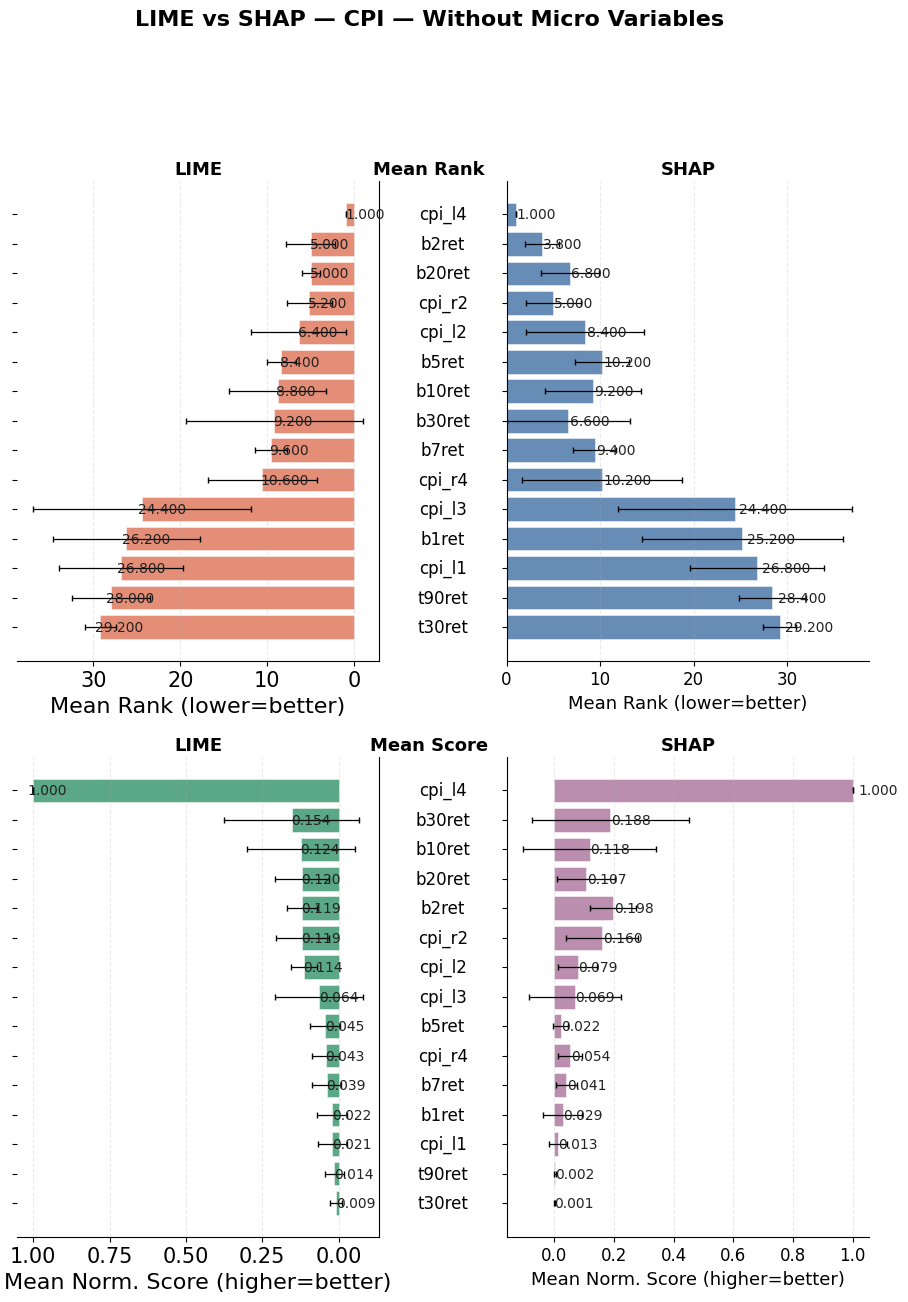


>>> LIME — GDP: ['XGB', 'GB', 'bayes', 'catboost']

MODEL AGREEMENT — Top 15 features per model
  cpiret                         ███        3/4 (75%)  [micro]
  unrate                         ███        3/4 (75%)  [macro]
  trade_balance                  ██         2/4 (50%)  [macro]
  gdp_roll4                      ██         2/4 (50%)  [micro]
  working_age_pop_lag1           ██         2/4 (50%)  [micro]
  gdp_lag1                       ██         2/4 (50%)  [macro]
  gdp_lag4                       ██         2/4 (50%)  [macro]
  labor_force_women_lag1         ██         2/4 (50%)  [micro]
  labor_force_men_lag1           ██         2/4 (50%)  [micro]
  labor_force_part_lag1          ██         2/4 (50%)  [micro]
  health_services_emp_lag1       ██         2/4 (50%)  [micro]
  b20ret                         ██         2/4 (50%)  [micro]
  gdp_roll8                      ██         2/4 (50%)  [micro]
  b30ret_lag1                    ██         2/4 (50%)  [micro]
  gdp_lag2           

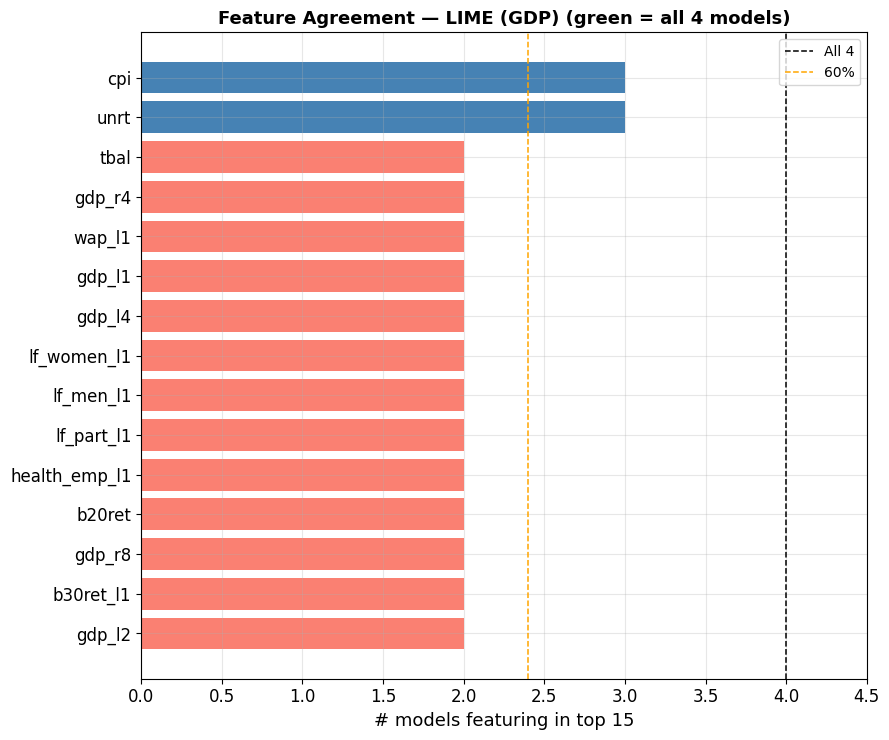


>>> SHAP — GDP: ['XGB', 'GB', 'bayes', 'catboost']

MODEL AGREEMENT — Top 15 features per model
  nfci_credit                    ████       4/4 (100%)  [macro]
  nfci_risk                      ███        3/4 (75%)  [macro]
  b30ret_lag1                    ███        3/4 (75%)  [micro]
  cpiret                         ███        3/4 (75%)  [micro]
  b7ret                          ██         2/4 (50%)  [micro]
  trade_balance                  ██         2/4 (50%)  [macro]
  gdp_lag1                       ██         2/4 (50%)  [macro]
  b20ret                         ██         2/4 (50%)  [micro]
  nfci_lag1                      ██         2/4 (50%)  [macro]
  b7ret_lag1                     ██         2/4 (50%)  [micro]
  b10ret_lag1                    ██         2/4 (50%)  [micro]
  anfci_lag1                     ██         2/4 (50%)  [macro]
  nfci                           ██         2/4 (50%)  [macro]
  nfci_leverage                  ██         2/4 (50%)  [macro]
  b20ret_lag1       

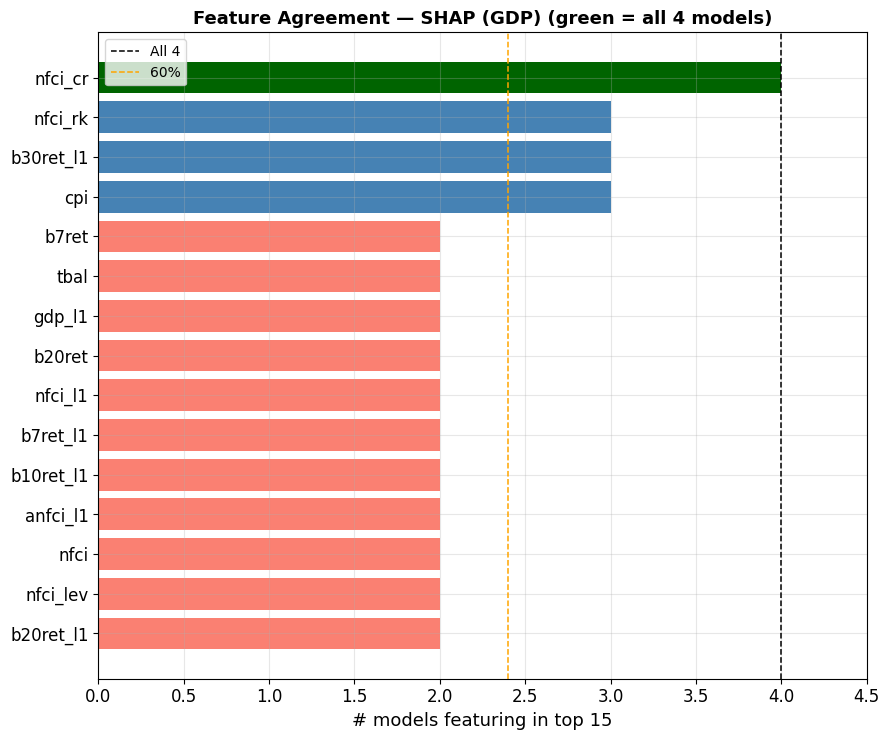

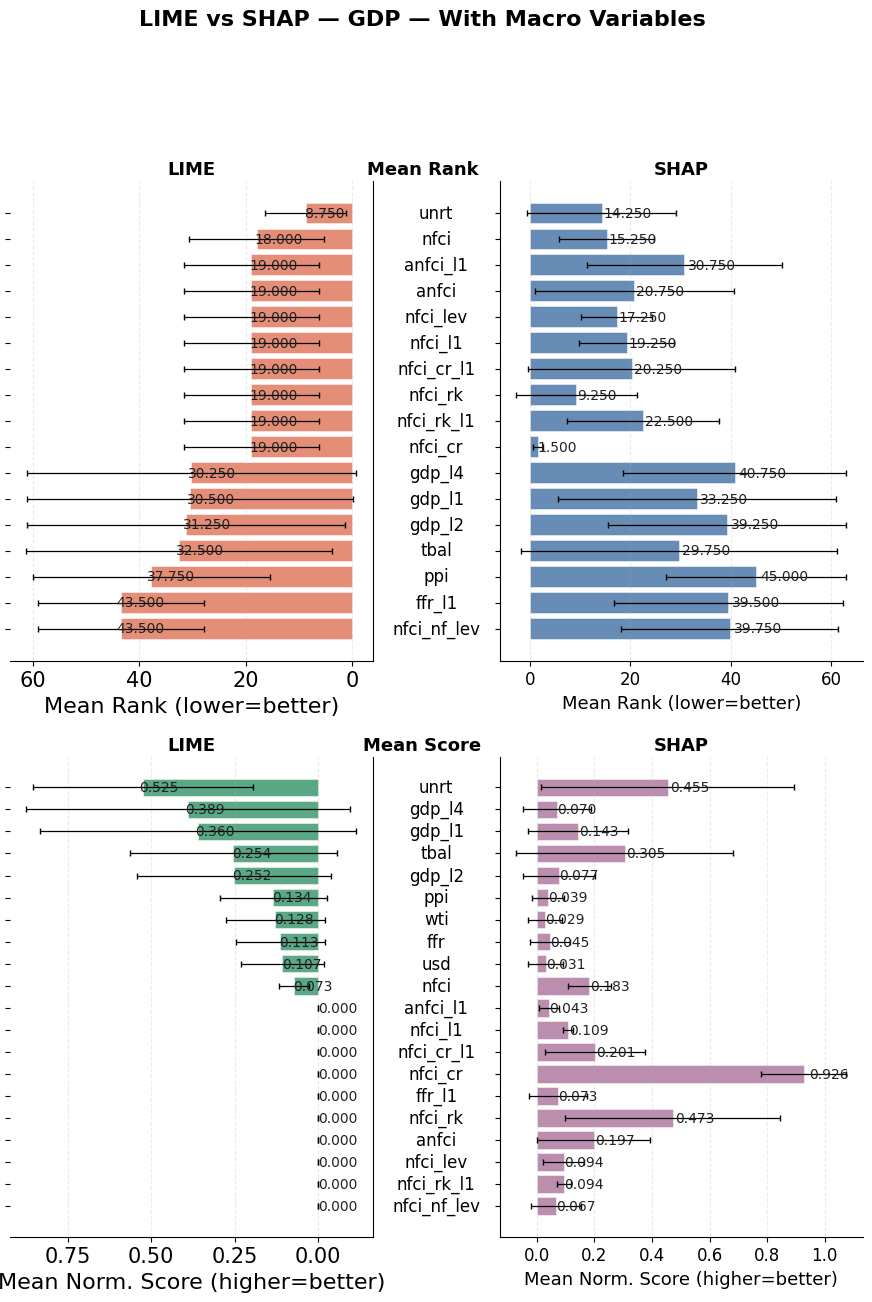

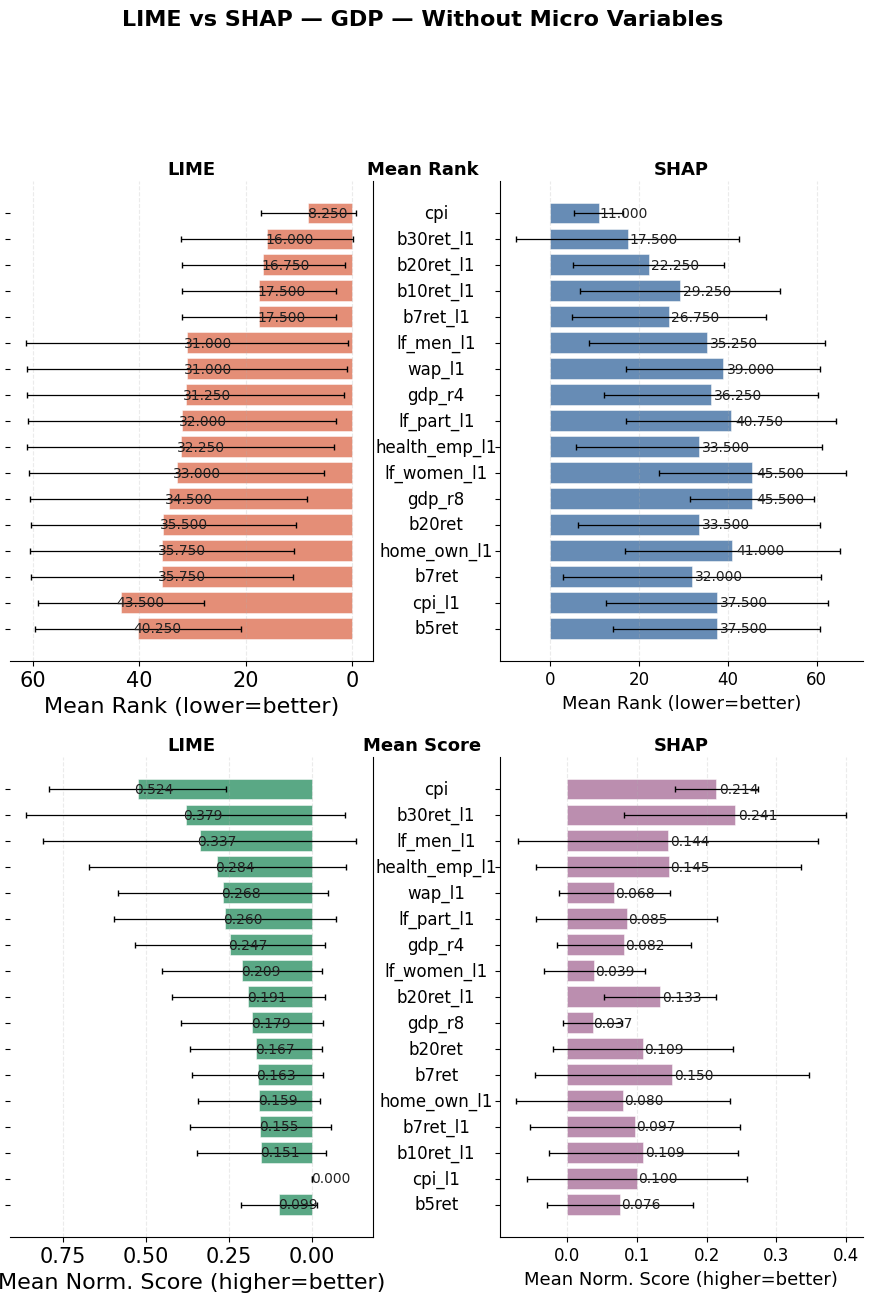

In [ ]:
import os
import re
import glob
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

_SHORTEN_PATTERNS = [
    (r'_lag(\d+)', r'_l\1'),
    (r'_roll(\d+)', r'_r\1'),
    (r'nonfinancial_leverage', 'nonfin_lev'),
    (r'leverage', 'lev'),
    (r'trade_balance', 'tbal'),
    (r'gdp_growth', 'gdp_gr'),
    (r'wti_price', 'wti'),
    (r'usd_index', 'usd'),
    (r'fedfunds', 'ffr'),
    (r'nfci_credit', 'nfci_cr'),
    (r'nfci_risk', 'nfci_rk'),
    (r'nfci_nonfin', 'nfci_nf'),
    (r'cpiret', 'cpi'),
    (r'unrate', 'unrt'),
    (r'working_age_pop', 'wap'),
    (r'labor_force_women', 'lf_women'),
    (r'labor_force_men', 'lf_men'),
    (r'labor_force_part', 'lf_part'),
    (r'health_services_emp', 'health_emp'),
    (r'homeownership_rate', 'home_own'),
]

def _shorten_label(feat: str) -> str:
    s = feat
    for pat, rep in _SHORTEN_PATTERNS:
        s = re.sub(pat, rep, s)
    return s.rstrip('_')


def _compute_all_methods(model_names, all_features, n_features,
                          rank_matrix, score_matrix) -> pd.DataFrame:
    borda_scores = sum(
        (n_features + 1) - rank_matrix[m] for m in model_names
    )
    mean_rank = rank_matrix.mean(axis=1)
    std_rank  = rank_matrix.std(axis=1)
    mean_score = score_matrix.mean(axis=1)
    std_score  = score_matrix.std(axis=1)

    combined = pd.DataFrame({
        'feature':          all_features,
        'borda_score':      borda_scores.values,
        'mean_rank':        mean_rank.values,
        'std_rank':         std_rank.values,
        'mean_score':       mean_score.values,
        'std_score':        std_score.values,
        'consistency':      (1 / (std_rank.values + 1e-6)),
        'var_group':        [_classify(f) for f in all_features],
    })
    return combined


def _compute_combined_df(importance_results: dict) -> pd.DataFrame:
    model_names, all_features, n_features, rank_matrix, score_matrix = \
        _build_matrices(importance_results)
    return _compute_all_methods(
        model_names, all_features, n_features, rank_matrix, score_matrix
    )

FS_TITLE    = 13
FS_SUPTITLE = 16
FS_LABEL    = 13
FS_TICK     = 12
FS_VALUE    = 10

DEFAULT_TOP_N = 15


def _build_shared_feature_order_across_methods(combined_lime, combined_shap,
                                                group_key, sort_col,
                                                ascending, top_n):
    lime_subset = (combined_lime[combined_lime['var_group'] == group_key]
                   .sort_values(sort_col, ascending=ascending)
                   .head(top_n))
    shap_subset = (combined_shap[combined_shap['var_group'] == group_key]
                   .sort_values(sort_col, ascending=ascending)
                   .head(top_n))

    lime_feats = lime_subset['feature'].tolist()
    shap_feats = shap_subset['feature'].tolist()

    shared_order = list(dict.fromkeys(lime_feats + shap_feats))
    return shared_order

def _plot_tornado_row(fig, gs_row, shared_features, combined_lime, combined_shap,
                       group_key, score_col, err_col, xlabel,
                       color_lime, color_shap, row_title):
    ax_left  = fig.add_subplot(gs_row[0])
    ax_mid   = fig.add_subplot(gs_row[1])
    ax_right = fig.add_subplot(gs_row[2], sharey=ax_left)

    lookup_lime = combined_lime[combined_lime['var_group'] == group_key].set_index('feature')
    lookup_shap = combined_shap[combined_shap['var_group'] == group_key].set_index('feature')

    scores_lime, errs_lime, in_lime = [], [], []
    scores_shap, errs_shap, in_shap = [], [], []
    for feat in shared_features:
        if feat in lookup_lime.index:
            scores_lime.append(lookup_lime.loc[feat, score_col])
            errs_lime.append(lookup_lime.loc[feat, err_col] if err_col else 0)
            in_lime.append(True)
        else:
            scores_lime.append(0.0)
            errs_lime.append(0.0)
            in_lime.append(False)

        if feat in lookup_shap.index:
            scores_shap.append(lookup_shap.loc[feat, score_col])
            errs_shap.append(lookup_shap.loc[feat, err_col] if err_col else 0)
            in_shap.append(True)
        else:
            scores_shap.append(0.0)
            errs_shap.append(0.0)
            in_shap.append(False)

    # reverse so top-ranked feature is at the top of the chart
    shared_r    = shared_features[::-1]
    scores_lime = scores_lime[::-1]; errs_lime = errs_lime[::-1]; in_lime = in_lime[::-1]
    scores_shap = scores_shap[::-1]; errs_shap = errs_shap[::-1]; in_shap = in_shap[::-1]

    display_features = [_shorten_label(f) for f in shared_r]
    y = range(len(shared_r))

    ax_left.barh(list(y), scores_lime, xerr=errs_lime if err_col else None,
                 color=color_lime, alpha=0.85, capsize=2.5,
                 error_kw={'linewidth': 0.9}, edgecolor='white', linewidth=0.4)
    ax_left.invert_xaxis()
    ax_left.set_yticks(list(y))
    ax_left.set_yticklabels([])   # no labels here — middle panel owns them
    ax_left.set_xlabel(xlabel, fontsize=FS_LABEL)
    ax_left.set_title("LIME", fontsize=FS_TITLE, fontweight='bold', pad=5)
    ax_left.tick_params(axis='x', labelsize=FS_TICK)
    ax_left.grid(True, axis='x', alpha=0.25, linestyle='--')
    ax_left.spines[['top', 'left']].set_visible(False)
    for i, (s, ok) in enumerate(zip(scores_lime, in_lime)):
        if not ok:
            continue
        ax_left.text(s * 1.02, i, f"{s:.3f}", va='center', ha='left',
                     fontsize=FS_VALUE, color='#222222')

    ax_mid.set_xlim(0, 1)
    ax_mid.set_ylim(ax_left.get_ylim())
    for i, feat in enumerate(display_features):
        ax_mid.text(0.5, i, feat, va='center', ha='center', fontsize=FS_TICK)
    ax_mid.axis('off')

    ax_right.barh(list(y), scores_shap, xerr=errs_shap if err_col else None,
                  color=color_shap, alpha=0.85, capsize=2.5,
                  error_kw={'linewidth': 0.9}, edgecolor='white', linewidth=0.4)
    ax_right.set_yticks(list(y))
    ax_right.set_yticklabels([])
    ax_right.set_xlabel(xlabel, fontsize=FS_LABEL)
    ax_right.set_title("SHAP", fontsize=FS_TITLE, fontweight='bold', pad=5)
    ax_right.tick_params(axis='x', labelsize=FS_TICK)
    ax_right.grid(True, axis='x', alpha=0.25, linestyle='--')
    ax_right.spines[['top', 'right']].set_visible(False)
    for i, (s, ok) in enumerate(zip(scores_shap, in_shap)):
        if not ok:
            continue
        ax_right.text(s * 1.02, i, f"{s:.3f}", va='center', ha='left',
                      fontsize=FS_VALUE, color='#222222')

    for i, (ok_l, ok_s) in enumerate(zip(in_lime, in_shap)):
        if not (ok_l and ok_s):
            ax_mid.texts[i].set_color('#bbbbbb')

    # row-level shared title above the trio
    fig.text(0.5, ax_mid.get_position().y1 + 0.002, row_title,
          ha='center', va='bottom', fontsize=FS_TITLE, fontweight='bold',
          transform=fig.transFigure)


def plot_group_comparison_tornado(method_results: dict, group_key: str,
                                   group_label: str, top_n: int = DEFAULT_TOP_N,
                                   save_name: str = "comparison.png",
                                   suptitle: str = "Feature Importance Comparison"):
    combined_lime = _compute_combined_df(method_results['lime'])
    combined_shap = _compute_combined_df(method_results['shap'])

    METRIC_CFG = [
        ('mean_rank', True, 'mean_rank', 'std_rank',
         'Mean Rank (lower=better)', '#E07A5F', '#4C78A8', 'Mean Rank'),
        ('mean_score', False, 'mean_score', 'std_score',
         'Mean Norm. Score (higher=better)', '#3D9970', '#B07AA1', 'Mean Score'),
    ]

    n_rows = len(METRIC_CFG)
    fig_height = n_rows * (top_n * 2 * 0.20 + 0.6)
    fig = plt.figure(figsize=(11, fig_height), constrained_layout=False)

    outer_gs = gridspec.GridSpec(n_rows, 1, figure=fig, hspace=0.20,
                              top=0.85, bottom=0.05)

    fig.suptitle(f"{suptitle} — {group_label}",
             fontsize=FS_SUPTITLE, fontweight='bold', y=0.98)

    for row_idx, (sort_col, ascending, score_col, err_col,
                  xlabel, color_lime, color_shap, metric_label) in enumerate(METRIC_CFG):

        shared_features = _build_shared_feature_order_across_methods(
            combined_lime, combined_shap, group_key, sort_col, ascending, top_n
        )

        row_gs = gridspec.GridSpecFromSubplotSpec(
            1, 3, subplot_spec=outer_gs[row_idx],
            width_ratios=[1, 0.32, 1], wspace=0.02
        )

        _plot_tornado_row(fig, row_gs, shared_features, combined_lime, combined_shap,
                           group_key, score_col, err_col, xlabel,
                           color_lime, color_shap, metric_label)

    plt.savefig(save_name, dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()

    return combined_lime, combined_shap


def plot_model_agreement(importance_results: dict, top_n: int = DEFAULT_TOP_N,
                          save_name: str = "model_agreement.png",
                          title_prefix: str = "Feature Agreement"):
    model_names = list(importance_results.keys())
    vote_counts = {}

    for model_name, fi_df in importance_results.items():
        for f in fi_df.nlargest(top_n, 'importance')['feature']:
            vote_counts[f] = vote_counts.get(f, 0) + 1

    vote_df = (pd.DataFrame({
        'feature': list(vote_counts.keys()),
        'votes':   list(vote_counts.values()),
        'group':   [_classify(f) for f in vote_counts]
    }).sort_values('votes', ascending=False).head(top_n).reset_index(drop=True))

    print(f"\n{'='*55}")
    print(f"MODEL AGREEMENT — Top {top_n} features per model")
    print(f"{'='*55}")
    for _, row in vote_df.iterrows():
        bar = '█' * row['votes']
        pct = row['votes'] / len(model_names) * 100
        print(f"  {row['feature']:<30} {bar:<10} "
              f"{row['votes']}/{len(model_names)} ({pct:.0f}%)  [{row['group']}]")
    print(f"{'='*55}")

    display_features = [_shorten_label(f) for f in vote_df['feature']]

    fig, ax = plt.subplots(figsize=(9, max(3.5, len(vote_df) * 0.5)))
    colors = ['darkgreen' if v == len(model_names)
              else 'steelblue' if v >= len(model_names) * 0.6
              else 'salmon'
              for v in vote_df['votes'][::-1]]
    ax.barh(display_features[::-1], vote_df['votes'][::-1], color=colors)
    ax.axvline(len(model_names), color='black', linestyle='--',
               linewidth=1.1, label=f'All {len(model_names)}')
    ax.axvline(len(model_names) * 0.6, color='orange', linestyle='--',
               linewidth=1.1, label='60%')
    ax.set_xlabel(f"# models featuring in top {top_n}", fontsize=FS_LABEL)
    ax.set_title(f"{title_prefix} (green = all {len(model_names)} models)",
                 fontsize=FS_TITLE, fontweight='bold')
    ax.tick_params(labelsize=FS_TICK)
    ax.set_xlim(0, len(model_names) + 0.5)
    ax.legend(fontsize=FS_TICK - 2)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_name, dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()

    return vote_df


DATA_DIR = "/content/drive/MyDrive/Forecasting-Agent-for-Fintech/data"

TARGETS = ["CPI", "GDP"]
METHODS = ["lime", "shap"]

all_vote_dfs = {}

for target in TARGETS:
    method_results = {}
    for method in METHODS:
        pattern = os.path.join(DATA_DIR, f"*_{method}_importance_{target}.csv")
        files = glob.glob(pattern)

        importance_results = {}
        for file in files:
            model_name = os.path.basename(file).replace(
                f"_{method}_importance_{target}.csv", ""
            )
            importance_results[model_name] = pd.read_csv(file)

        print(f"\n>>> {method.upper()} — {target}: {list(importance_results.keys())}")

        if not importance_results:
            print(f"    No files found for pattern: {pattern}")
            continue

        method_results[method] = importance_results

        all_vote_dfs[f"{method}_{target}"] = plot_model_agreement(
            importance_results,
            top_n=DEFAULT_TOP_N,
            save_name=f"model_agreement_{method}_{target}.png",
            title_prefix=f"Feature Agreement — {method.upper()} ({target})"
        )

    if len(method_results) == 2:
        plot_group_comparison_tornado(
            method_results, group_key='macro', group_label='With Macro Variables',
            top_n=DEFAULT_TOP_N,
            save_name=f"comparison_{target}_macro.png",
            suptitle=f"LIME vs SHAP — {target}"
        )
        plot_group_comparison_tornado(
            method_results, group_key='micro', group_label='Without Micro Variables',
            top_n=DEFAULT_TOP_N,
            save_name=f"comparison_{target}_micro.png",
            suptitle=f"LIME vs SHAP — {target}"
        )